# **Algiers in 24 Hours - Tourist Optimizer**

---
# **SECTION 0 - Imports and Global Configuration**

In [2]:
TMAX_FULL = 720
TMAX_HALF = 360
STARTING_TIME = 480



## Imports

In [24]:
from pathlib import Pathimport random, time, math, os
from typing import List, Dict, Any,  Tuple, Set, Union, Literal

import pandas as pd
import numpy as np

from utils.data_loader import get_landmarks, get_hotels, get_time_matrix

import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')


In [4]:
%pip install matplotlib seaborn pandas numpy

Note: you may need to restart the kernel to use updated packages.


---
# **SECTION 1 - Data Collection**
## 1.1 - Landmarks Dataset

We gathered - clean - data about  **+60 attractions/landmarks in Algiers**, including the following attributes:  
* __Attraction/landmark name.__
* __Description (__ short description __)__  
* __Type of attraction/landmark (__ Monument, Park/Garden, Historical site ... etc __)__  
* __Rating (/10)__ 
* __GPS coordinates (__ longitude, latitude __)__
* __Estimated visit duration (__ in minutes  __)__
* __Opening Hours__
* __Images__

import csv
from collections import Counter

#### path to the landmarks CSV file
LANDMARK_PATH = "./../dataset/landmarks/Algiers_landmarks.csv"

with open(LANDMARK_PATH, newline='', encoding='utf-8') as f:
    rows = list(csv.DictReader(f))

ratings = [float(r['Rating']) for r in rows]
types = Counter(r['Type'] for r in rows)


print(f"Total landmarks : {len(rows)}")
print(f"Average rating  : {sum(ratings)/len(ratings):.2f}")
print(f"Highest rating  : {max(ratings)}")
print(f"Lowest rating   : {min(ratings)}")
print(f"Unique types    : {len(types)}")


print("\nCount by type: ")
for t, c in types.most_common():
    print(f"  {t:<25} {c}")


print("\nTop 10 landmarks: ")
for i, r in enumerate(sorted(rows, key=lambda x: float(x['Rating']), reverse=True)[:10], 1):
    print(f"  {i:>2}. {r['Rating']}  {r['Name']}")

print("\nBottom 5 landmarks: ")
for i, r in enumerate(sorted(rows, key=lambda x: float(x['Rating']))[:5], 1):
    print(f"  {i}. {r['Rating']}  {r['Name']}")
## 1.2 - Hotels Dataset

We gathered a dataset of __+180 hotels__ across the Algiers region, collected from Google Maps.
HOTELS_PATH = "./../dataset/hotels/Algiers_hotels.csv"

with open(HOTELS_PATH, newline='', encoding='utf-8') as f:
    rows = list(csv.DictReader(f))
 
print(f"Total hotels: {len(rows)}")
## 1.3 - Time Matrix

Generated via the OSRM public API (router.project-osrm.org) using the driving profile.

- `time_matrix.npy` — (247 × 247) numpy array of travel times in minutes
- `time_matrix_named.csv` — same matrix with landmark/hotel names as row and column headers

Rows and columns are ordered: landmarks first (83), hotels second (184).

**Note:** The public OSRM API enforces a 100-coordinate limit per request,
so the matrix is built in batches. Results reflect road-network driving time
and may not account for real-time traffic.
import pandas as pd
import numpy as np
import requests

landmarks = pd.read_csv("./../dataset/landmarks/final_dataset.csv")
hotels    = pd.read_csv("./../dataset/hotels/Algiers_hotels.csv")

names = list(landmarks["Name"]) + list(hotels["name"])

all_coords = (
    [(row["Longitude"], row["Latitude"]) for _, row in landmarks.iterrows()] +
    [(row["longitude"], row["latitude"]) for _, row in hotels.iterrows()]
)

OSRM_BASE = "http://router.project-osrm.org/table/v1/driving"
BATCH     = 100  # public OSRM hard limit

n = len(all_coords)
time_matrix = np.zeros((n, n), dtype=float)

for i in range(0, n, BATCH):
    for j in range(0, n, BATCH):
        src_slice = all_coords[i:i+BATCH]
        dst_slice = all_coords[j:j+BATCH]

        combined = src_slice + dst_slice
        coords_str = ";".join(f"{lon},{lat}" for lon, lat in combined)

        sources = ";".join(str(k) for k in range(len(src_slice)))
        destinations = ";".join(str(k + len(src_slice)) for k in range(len(dst_slice)))

        r = requests.get(
            f"{OSRM_BASE}/{coords_str}",
            params={"annotations": "duration", "sources": sources, "destinations": destinations},
            timeout=120
        )
        r.raise_for_status()
        block = np.array(r.json()["durations"], dtype=float) / 60  # seconds → minutes

        time_matrix[i:i+len(src_slice), j:j+len(dst_slice)] = block

np.save("time_matrix.npy", time_matrix)

df = pd.DataFrame(time_matrix.round(1), index=names, columns=names)
df.to_csv("time_matrix_named.csv")

print(f"Done. Matrix shape: {time_matrix.shape}")
The CSV file `time_matrix_named.csv` is converted into a JSON file `time_matrix.json`
import pandas as pd
import json

# load the existing matrix CSV
df = pd.read_csv("time_matrix_named.csv", index_col=0)

# convert to nested dict {start: {end: minutes}}
time_dict = {}
for start in df.index:
    time_dict[start] = {}
    for end in df.columns:
        time_dict[start][end] = round(float(df.loc[start, end]), 1)

# save as JSON
with open("time_matrix.json", "w", encoding="utf-8") as f:
    json.dump(time_dict, f, ensure_ascii=False, indent=2)

print("Done. Saved to time_matrix.json")

In [5]:
# print all the landmarks to discover the types and the number of each type , different range of ratings 
# statistics about openning and closing hours 
# statistics about visiting time and all other column's data 


#  printing subset from hotels and some informations about them

you can inspire from the last yesr's notebook

---
# **SECTION 2 -  Core Classes**



## 2.1 - Landmark and Hotel Classes

In [6]:
class Landmark:
    """
    Represents a single tourist landmark or attraction.

    Attributes:
        id (int): A unique numerical identifier for the landmark.
        name (str): The name of the landmark.
        lon (float): Longitude coordinate.
        lat (float): Latitude coordinate.
        interest_score (float): The rating or user interest score.
        opening_hours (dict[str, list[int]]): A dictionary mapping days of the week
            (e.g., 'Monday') to a list of 24 integers representing hours.
            1 means open, 0 means closed. Example: {'Monday': [0,0,...,1,1,0]}
        visit_duration (int): Estimated time spent at the landmark in minutes.
        landmark_type (str): The category of the landmark (e.g., 'Museum', 'Park').
    """

    def __init__(
        self,
        id: int,
        name: str,
        lon: float,
        lat: float,
        interest_score: float,
        opening_hours: dict[str, list[int]],
        visit_duration: int,
        landmark_type: str,
    ):

        self.id = id
        self.name = name
        self.lon = lon
        self.lat = lat
        self.interest_score = interest_score
        self.opening_hours = opening_hours
        self.visit_duration = visit_duration
        self.landmark_type = landmark_type

    # check this , since we will be working with minutes and time matrix is in minutes we wont be doing conversion from min to hours

    def is_open(self, day: str, arrival_minutes: float) -> bool:
        """
        Checks if the landmark is open for the entire visit duration.
    
        Args:
            day(str): Day abbreviation e.g. 'mon', 'tue'
            arrival_minutes (float): Arrival time in minutes from midnight
                                    e.g. 540 = 09:00, 545.7 = 09:05:42

        Returns:
            bool: True if landmark is open for every hour slot of the visit
        """
        opening = self.opening_hours[day]
       
        if opening is None:
            print("no openning hour provided")
            return False

        finish_minutes = arrival_minutes + self.visit_duration

        # which hour slot do we arrive in?
        arrival_hour = int(arrival_minutes // 60)

        # which hour slot are we still INSIDE at the end?
        # subtract 1 so that finishing exactly on the hour (e.g. 600 = 10:00)
        # does not count as being inside the next slot (hour 10)
        finish_hour = int((finish_minutes - 1) // 60)

        for hour in range(arrival_hour, finish_hour + 1):
            if opening[hour % 24] == 0:
                
                return False
        
        return True


In [7]:
#this class represent single hotel

class Hotel:
    """
    Single Hotel Object 

    Attributes:

        id : name of the hotel from the dataset
           
    """

    def __init__(self, name, lon, lat):
        self.id = name
        self.name = name
        self.lon = lon
        self.lat = lat

# **3 - Problem Formulation**

## **3.1 - State Representation**

#### Informed Search 

 explanation and tuples of all the variables ( no code ) 

#### Local Search 

 explanation and tuples of all the variables ( no code ) 

#### CSP

 explanation and tuples of all the variables ( no code ) 

#### Ant Colony System  

 explanation and tuples of all the variables ( no code ) 

## **3.2 - Class For Problem Formulation**

#### **Informed Search Problem Class**

code fully documented and commented

In [8]:
#python code

#### **Local Search Problem Class**

code fully documented and commented

In [9]:


class TravelProblem_LocalSearch:
    """
    This class represents the travel guide problem formulation for Local Search algorithms.
    It manages state validation, neighbor generation, and state evaluation for a 24-hour trip.
    """

    def __init__(self, landmarks: List['Landmark'], travel_information: Dict[str, Any]):
        """
        Initializes the travel problem with landmarks and user preferences.

        Args:
            landmarks: A list of Landmark objects available to visit.
            travel_information: A dictionary containing user preferences and constraints.
                Expected keys:
                - 'hotel': Hotel object (starting and ending point).
                - 'Travel_day': three lettter string  (e.g., 'mon' , 'fri' ).
                - 'Travel_Time': float (Max travel time allowed in hours).
                - 'type_filter': list[str] (Allowed categories, e.g., ['Museum', 'Park']).
                - 'time_matrix': dict (Precomputed travel times in minutes between locations).
                - 'trip_start_time': int ( the starting hour of the trip )

        """
        if not landmarks:
            raise ValueError("No list of landmarks provided!")
        
        self.landmarks = landmarks
        self.landmarks_list = [landmark.name for landmark in landmarks]
        
        # Extract user preferences and constraints
        self.hotel = travel_information['hotel']
        self.Travel_day = travel_information['Travel_day']
        self.max_travel_time = travel_information['Travel_Time'] 
        if self.max_travel_time > 24 :
            raise ValueError("travel time should be less than 24 hours !")

      
        self.type_filter = travel_information['type_filter']

        self.trip_start_time = travel_information['trip_start_time']
        # Important: The time matrix must be passed in to calculate real road travel times
        self.time_matrix = travel_information['time_matrix']
        self.trip_start_time = travel_information['trip_start_time']

        # Generate the initial starting state (must be done AFTER setting rules)
        self.initial_state = self._generate_random_state()


    def valid_state(self, state: List['Landmark'], hard_constraints: bool = True, is_building: bool = False) -> bool:
        """
        Validates an itinerary based on time limits, opening hours, and category filters.
        Checks if the trip starts and ends at the hotel.
        """
        # 1. Quick Failure Checks: Null values or duplicate landmarks
        if not state:
            return False
        if None in state: 
            return False
        if len(set(lm.id for lm in state)) != len(state): 
            return False

        # Current time with minutes  
        current_time = self.trip_start_time * 60

        # 2. Iterate through the itinerary to track time and check constraints
        for i, landmark in enumerate(state):
            # Add travel time to get to this landmark
            if i == 0:
                # Travel from hotel to first landmark
                travel_mins = self.time_matrix[self.hotel.id][landmark.name]
               
            else:
                # Travel between landmarks
                travel_mins = self.time_matrix[state[i-1].name][landmark.name]
                            
            # Arrival time in minutes 
            current_time += travel_mins

            # Check if landmark is open at arrival
            if not landmark.is_open(self.Travel_day, (current_time % 1440)):
                return False
            
            if self.type_filter and landmark.landmark_type not in self.type_filter: 
                return False

              
            # Add the duration spent visiting the landmark (in minutes)
            current_time += landmark.visit_duration 

        # 3. Add the return trip to the hotel (Ensures it ends at hotel)
        return_mins = self.time_matrix[state[-1].name][self.hotel.id]
        current_time += return_mins 
        
        return_hour = current_time / 60
        
        # 4. Hard Constraint: Did the total trip exceed the user's allowed time?
        if hard_constraints:

            duration = return_hour - self.trip_start_time
            if duration > self.max_travel_time :        
                return False
            
            if not is_building:
                if duration < max(0, self.max_travel_time - 2):
                    return False
            
        return True
    


    def _generate_random_state(self) -> List['Landmark']:
        """
        Generates a valid, random initial state to kick off the search.
        
        """
        # using the landmark number if provided 
        

        # without using the landmark number    
        
        state = []

        failure = 0 
        while failure < 500: 
            try_state =  state.copy()
            item = random.choice(self.landmarks)
            if item not in state : 
                try_state.append(item)
            else :
                continue

            if not self.valid_state(try_state, is_building=True) : 
                    failure +=1 
                    continue
                
            state = try_state 
     
        return state
    

    
    def generate_neighbors(self, state: List['Landmark']) -> List[List['Landmark']]:
        """
        Generates all legally valid neighbors using two strategies:
        1. Replacement: Swapping an existing landmark for an unused one.
        2. Internal Swap: Changing the order of current landmarks.
        3. If the itinerary size is dynamic, also uses Add and Remove.
        """
        neighbors = set()
        current_ids = [landmark.id for landmark in state]

        # --- Strategy 1: Replacement Neighbors ---
        for i, landmark in enumerate(state):
            for new_item in self.landmarks:
                if new_item.id not in current_ids:
                    state_copy = state[:]  
                    state_copy[i] = new_item
                    
                    if self.valid_state(state_copy): 
                        neighbors.add(tuple(state_copy))

                        

        # --- Strategy 2: Internal Swap Neighbors ---
        for i in range(len(state)):
            for j in range(i + 1, len(state)):
                state_copy = state[:]
                # Swap the positions
                state_copy[i], state_copy[j] = state_copy[j], state_copy[i]
                
                if self.valid_state(state_copy):
                    neighbors.add(tuple(state_copy))


      
            
        # --- Strategy 3: ADD a landmark ---
        for new_item in self.landmarks:
                if new_item.id not in current_ids:
                    # Try inserting the new item at every possible step of the trip
                    # range(len(state) + 1) allows us to put it at the very start, middle, or very end
                    for insert_index in range(len(state) + 1):
                        state_copy = state[:]
                        state_copy.insert(insert_index, new_item)
                        
                        if self.valid_state(state_copy):
                            neighbors.add(tuple(state_copy))

        # --- Strategy 4: REMOVE a landmark ---
         # We should only allow removing if the trip has more than 1 stop left!
        if len(state) > 1:
                for i in range(len(state)):
                    state_copy = state[:]
                    state_copy.pop(i)  # Remove the landmark at index i
                    
                    if self.valid_state(state_copy):
                        neighbors.add(tuple(state_copy))            

        return [list(s) for s in neighbors]
    


    def _generate_random_neighbor(self, state: List['Landmark']) -> List['Landmark']:
        """Returns one random valid neighbor from the current state."""
        neighbors = self.generate_neighbors(state)
        # Fallback if no neighbors are found (rare, but prevents crashes)
        if not neighbors:
            return state 
        return random.choice(neighbors)
    


    def evaluate(self, state: List['Landmark']) -> float:
        """ 
        The Fitness Function. 
        Maximizes the interest score while relative to distance.
        A higher resulting float indicates a better itinerary.
        """ 
        total_rating = 0
        total_travel_time = 0 

        for i, landmark in enumerate(state):
            total_rating += landmark.interest_score
            
            # Travel time from hotel to first landmark, or between landmarks
            if i == 0:
                total_travel_time += self.time_matrix[self.hotel.id][landmark.name]
            else:
                total_travel_time += self.time_matrix[state[i-1].name][landmark.name]

        # Travel time from final landmark back to the hotel
        total_travel_time += self.time_matrix[state[-1].name][self.hotel.id]

        # Standard Comparative Score: 
        # Focus on maximizing Interest Score (heavily weighted) 
        # while subtracting travel time costs.
        RATING_WEIGHT = 7 # I tested with 7 and 5 and I didn't see a big change
        # Invert the logic: (Rating * Weight) - travel_time - Maximizing 
        score = (RATING_WEIGHT * total_rating) - total_travel_time
        
        return score
    
    def distance(self, loc1: Any, loc2: Any) -> float:
        """
        Calculates the Great-Circle (Haversine) distance
        Accepts both Landmark and Hotel objects (duck typing) since both have .lat and .lon.
        """
        
        # radius of earth in kilometers 
        R = 6371.0
        lat1 = math.radians(loc1.lat)
        lon1 = math.radians(loc1.lon)
        lat2 = math.radians(loc2.lat)
        lon2 = math.radians(loc2.lon)

        dlon = lon2 - lon1
        dlat = lat2 - lat1

        a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos( lat2) * math.sin(dlon / 2)**2
        c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

        distance_km = R * c
        
        return distance_km

### ***OPTIONAL ONES***

#### **CSP Problem Class**

code fully documented and commented

In [10]:
# This class holds everything the algorithms need and give clean access to it.

#### **ACS and ACS's Environment Class**

code fully documented and commented

In [36]:
class ACSEnvironment:
    """
    Acts as the 'Map' or 'Game Engine' for the Ant Colony System.
    Manages the travel times, time constraints, and the Pheromone Matrix memory.
    """

    def __init__(
        self,
        hotel: Hotel,
        landmarks: List[Landmark],
        time_matrix: Dict[str, Dict[str, float]],
        time_budget_hours: float,    
        trip_start_time_hours: float, 
        visiting_day: str,
    ) -> None:
        """
        Initializes the Ant Colony Environment.
        
        Args:
            hotel (Hotel): The starting and ending location of the trip.
            landmarks (List[Landmark]): A list of all available Landmark objects.
            time_matrix (Dict[str, Dict[str, float]]): 2D dictionary of travel times in minutes.
            time_budget_hours (float): Total allowed duration of the trip in hours.
            trip_start_time_hours (float): Starting time of the trip (0.0 to 23.99).
            visiting_day (str): The day of the week (e.g., 'mon', 'tue').
        """
        self.hotel: Hotel = hotel
        self.landmarks: List[Landmark] = landmarks
        self.time_matrix: Dict[str, Dict[str, float]] = time_matrix

        # Convert time units from hours to minutes for internal calculations
        self.time_budget: float = time_budget_hours * 60.0 
        self.starting_time: float = trip_start_time_hours * 60.0 
        self.visiting_day: str = visiting_day.lower()
        
        # Initialize the Pheromone Matrix
        self.matrix: Dict[str, Dict[str, float]] = self._initialize_pheromones()

    def _initialize_pheromones(self) -> Dict[str, Dict[str, float]]:
        """
        Creates the memory bank for the ants. Uses node names as dictionary keys.
        
        Returns:
            Dict[str, Dict[str, float]]: A 2D dictionary initialized with default pheromone levels (1.0).
        """
        matrix: Dict[str, Dict[str, float]] = {}
        all_nodes: List[Union[Hotel, Landmark]] = [self.hotel] + self.landmarks
        
        for from_node in all_nodes:
            matrix[from_node.name] = {}
            for to_node in all_nodes:
                if from_node.name != to_node.name:
                    matrix[from_node.name][to_node.name] = 1.0 # Default baseline smell
        return matrix

    def get_travel_time(self, from_node: Union[Hotel, Landmark], to_node: Union[Hotel, Landmark]) -> float:
        """
        Retrieves the travel time between two nodes.
        
        Args:
            from_node (Hotel | Landmark): The starting node object.
            to_node (Hotel | Landmark): The destination node object.
            
        Returns:
            float: The travel time in minutes.
        """
        return self.time_matrix[from_node.name][to_node.name]

    def get_valid_next_moves(
        self, 
        current_node: Union[Hotel, Landmark], 
        current_time_minutes: float, 
        visited_objects: Set[str]
    ) -> List[Landmark]:
        """
        The 'Bouncer': Evaluates all landmarks and returns only the ones that can be legally visited.
        
        Args:
            current_node (Hotel | Landmark): Where the ant currently is.
            current_time_minutes (float): The ant's current clock time.
            visited_objects (Set[str]): A set containing the names of already visited nodes.
            
        Returns:
            List[Landmark]: A filtered list of Landmark objects that are open and reachable.
        """
        valid_moves: List[Landmark] = []
        
        for landmark in self.landmarks:
            if landmark.name in visited_objects:
                continue
                
            travel_time = self.get_travel_time(current_node, landmark)
            arrival_time = current_time_minutes + travel_time
            
            # Check if landmark is open upon arrival and for the duration of the visit
            if not landmark.is_open(self.visiting_day, arrival_time):
                continue
                
            time_after_visit = arrival_time + landmark.visit_duration
            time_to_get_home = self.get_travel_time(landmark, self.hotel)
            
            # Check if ant can complete the visit and return to hotel before budget expires
            if (time_after_visit + time_to_get_home) <= (self.starting_time + self.time_budget):
                valid_moves.append(landmark)
                
        return valid_moves
        
    def evaporate_and_reinforce(self, top_trips: List[Tuple[List[Union[Hotel, Landmark]], float]], rho: float = 0.1, tau_min: float = 0.01) -> None:
        """
        Updates the Pheromone Matrix at the end of a generation.
        
        Args:
            top_trips (List[Tuple[List, float]]): The best trips of the generation, sorted by score.
            rho (float): The evaporation rate (percentage of pheromone lost). Default is 0.1 (10%).
            tau_min (float): The absolute minimum pheromone level allowed to force exploration.
        """
        # 1. Evaporate all trails
        for from_name in self.matrix:
            for to_name in self.matrix[from_name]:
                self.matrix[from_name][to_name] *= (1.0 - rho)
                
                # Apply the Pheromone Floor to prevent division by zero or permanent dead ends
                if self.matrix[from_name][to_name] < tau_min:
                    self.matrix[from_name][to_name] = tau_min
                    
        # 2. Reinforce the TOP ants
        # FIX: Since trips contain 15-20 landmarks, total scores can reach 150-200.
        # A Q of 0.05 scales a massive score of 200 down to a healthy pheromone drop of 10.0.
        Q: float = 0.2
        #previous value 0.05 
        weight: float = 1.0 # The #1 ant drops 100%, #2 drops 80%, etc.
        
        for trip_objects, score in top_trips:
            pheromone_drop = (Q * score) * weight 
            
            for i in range(len(trip_objects) - 1):
                from_name = trip_objects[i].name
                to_name = trip_objects[i+1].name
                self.matrix[from_name][to_name] += pheromone_drop
                
            # Decrease the weight for the next ant down the leaderboard
            weight *= 0.8

## **3.3 - Solution Class**

In [12]:
# this class print in unified way the results of each algorithm , we should agree on using it 

---
# **SECTION 3 - Algorithms**


## Greedy , Simulated Anealing , GA + optional Ones


code impelmentation + definition of each algorithm and of each parameter  , 
a lot of docuementation should be here for everything

definition for each algorithm , the role of each paramter 

explain each decision we make and each variable we choose

## **Main Algorithms**

### ***Gready Algorithm***

explanation and docuementation

In [13]:
#code for the algorithm

### ***Simulated Annealing Algorithm***

explanation and docuementation

In [14]:


class Simulated_Annealing:
    """      
    Simulated Annealing implementation for the Travel Guide problem.
    Features: 
    - Adaptive Cooling
    - Reheating (Local Optima Escape)
    - Multi-stage search (Multi-restart with memory)
    """

    def __init__(self, problem: TravelProblem_LocalSearch, initial_temp: float = 100.0, cooling_rate: float = 0.98, min_temp: float = 0.001, max_reheats: int = 3):
        """
        Initializes the Simulated Annealing algorithm.

        Args:
            problem: An instance of TravelProblem_LocalSearch.
            initial_temp: The starting temperature for the annealing process.
            cooling_rate: The rate at which the temperature decreases.
            min_temp: The temperature at which the algorithm stops.
            max_reheats: Maximum number of times to perform reheating.
        """
        self.problem = problem
        self.initial_temp = initial_temp
        self.temp = initial_temp
        self.cooling_rate = cooling_rate
        self.min_temp = min_temp
        self.max_reheats = max_reheats

    def calculate_fitness(self, state: List[Landmark]) -> float:
        """
        Calculates the fitness of a state by delegating to the problem's evaluate method.
        Higher is better (maximization).
        """
        if not self.problem.valid_state(state):
            return -float('inf')
        
        return self.problem.evaluate(state)
    

    def run(self) -> List[Landmark]:
        """
        Executes the Simulated Annealing search.
        Strictly follows the local search paradigm: moving from current state to neighbor.

        Returns:
            The best itinerary (list of Landmarks) found.
        """
        # Diversity memory (Tabu-lite) to avoid cycles within the local neighborhood
        tabu_list = []
        max_tabu_size = 20
        
        # Start at the provided initial state (Local Search requirement)
        current_state = self.problem.initial_state
        current_fitness = self.calculate_fitness(current_state)
        
        best_overall_state = current_state
        best_overall_fitness = current_fitness

        reheat_count = 0
        stagnation_counter = 0
        max_stagnation = 150 

        while reheat_count <= self.max_reheats:
            # Temperature acts as the probability threshold for accepting 'down-hill' moves
            self.temp = self.initial_temp * (1.0 / (reheat_count + 1)) 
            
            while self.temp > self.min_temp:
                # 1. Neighbor Generation: Explore the local neighborhood of the CURRENT state
                neighbors = self.problem.generate_neighbors(current_state)
                
                if not neighbors:
                    break

                # 2. Select a neighbor (using Tabu-lite to ensure we don't oscillate locally)
                valid_neighbors = [n for n in neighbors if tuple(lm.id for lm in n) not in tabu_list]
                neighbor = random.choice(valid_neighbors) if valid_neighbors else random.choice(neighbors)
                
                neighbor_fitness = self.calculate_fitness(neighbor)
                delta_e = current_fitness - neighbor_fitness # Maximization: current - neighbor

                # 3. Acceptance Criterion: Local search moves to a neighbor
                if delta_e < 0:
                    # Improvement move (neighbor is better)
                    current_state = neighbor
                    current_fitness = neighbor_fitness
                    stagnation_counter = 0 
                    
                    if current_fitness > best_overall_fitness:
                        best_overall_state = neighbor
                        best_overall_fitness = current_fitness
                else:
                    # Probabilistic move (Escape local optima)
                    # For maximization: P = exp(-(current - neighbor) / T)
                    acceptance_prob = math.exp(-delta_e / max(self.temp, 1e-10))
                    if random.random() < acceptance_prob:
                        current_state = neighbor
                        current_fitness = neighbor_fitness
                    
                    stagnation_counter += 1

                # Update Tabu List for local diversity
                state_id = tuple(lm.id for lm in current_state)
                tabu_list.append(state_id)
                if len(tabu_list) > max_tabu_size:
                    tabu_list.pop(0)

                # 4. Cooling: Move from exploration to exploitation
                if stagnation_counter == 0:
                    effective_cooling = 1.0 - (1.0 - self.cooling_rate) * 0.3 
                else:
                    effective_cooling = self.cooling_rate

                self.temp *= effective_cooling

                if stagnation_counter > max_stagnation:
                    break

            # 5. Reheating (Iterative Local Search): Restart from best or random to find new basins
            reheat_count += 1
            if reheat_count <= self.max_reheats:
                # To maintain local search integrity, we jump to a new starting point
                current_state = self.problem._generate_random_state()
                current_fitness = self.calculate_fitness(current_state)
                stagnation_counter = 0

        return best_overall_state

    def __str__(self):
        return f"Simulated Annealing (Best Fitness: {self.temp})"


### ***Genetic Algorithms***

explanation and docuementation

In [15]:
#code for the algorithm
class Genetic_Algorithm:
    def __init__(self, problem: TravelProblem_LocalSearch, population_size: int, generations: int, mutation_rate: float):
        self.problem = problem
        self.population_size = population_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.population = self.generate_population()

    def __str__(self):
        return f"Genetic Algorithm with population size {self.population_size}, generations {self.generations}, and mutation rate {self.mutation_rate}"
    

    # Generating Population

    def generate_population(self):
          
        population = []
        trip_start_time = self.problem.trip_start_time
        for _ in range(self.population_size):
            shuffled = self.problem.landmarks[:]
            random.shuffle(shuffled)
            individual = []
            current_time = trip_start_time * 60  

            for landmark in shuffled:
                if not individual:
                    travel_mins = self.problem.time_matrix[self.problem.hotel.id][landmark.name]
                else:
                    travel_mins = self.problem.time_matrix[individual[-1].name][landmark.name]

                arrival_time = current_time + travel_mins

                # If closed at arrival, try waiting until it opens
                if not landmark.is_open(self.problem.Travel_day, arrival_time % 1440):
                    opening = landmark.opening_hours[self.problem.Travel_day]
                    if opening is None:
                        continue
                    hour = int(arrival_time // 60) + 1
                    waited = False
                    while hour < 24:
                        if opening[hour % 24] == 1:
                            wait_arrival = hour * 60
                            return_mins = self.problem.time_matrix[landmark.name][self.problem.hotel.id]
                            finish_time = wait_arrival + landmark.visit_duration + return_mins
                            if (finish_time / 60) - trip_start_time <= self.problem.max_travel_time:
                                arrival_time = wait_arrival
                                waited = True
                            break
                        hour += 1
                    if not waited:
                        continue

                if self.problem.type_filter and landmark.landmark_type not in self.problem.type_filter:
                    continue

                return_mins = self.problem.time_matrix[landmark.name][self.problem.hotel.id]
                finish_time = arrival_time + landmark.visit_duration + return_mins
                if (finish_time / 60) - trip_start_time > self.problem.max_travel_time:
                    continue

                individual.append(landmark)
                current_time = arrival_time + landmark.visit_duration

            population.append(individual)
        return population

    # Fitness Function

    def calculate_fitness(self, individual: List['Landmark']) -> float:
        return self.problem.evaluate(individual)

    # Selection Methods

    def tournament_selection(self, tournament_size: int):
        tournament_players = random.sample(self.population, tournament_size)
        winner = tournament_players[0]
        winner_fitness = self.calculate_fitness(winner)
        for player in tournament_players[1:]:
            current_fitness = self.calculate_fitness(player)
            if current_fitness > winner_fitness:
                winner = player
                winner_fitness = current_fitness
        return winner
        
    def roulette_wheel_selection(self, k: int):
        
        fitnesses = [max(0, self.calculate_fitness(ind)) for ind in self.population]
        
        if sum(fitnesses) == 0:
            return random.choices(self.population, k=k)
        
        return random.choices(self.population, weights=fitnesses, k=k)

    def rank_selection(self, k: int):
            fitnesses = [self.calculate_fitness(ind) for ind in self.population]
            
            sorted_population = [ind for _, ind in sorted(zip(fitnesses, self.population), key=lambda pair: pair[0])]

            ranks = list(range(1, len(self.population) + 1))
            
            parents = random.choices(sorted_population, weights=ranks, k=k)

            return parents

    # Crossover Methods

    # not good for our problem since it can produce invalid sols ( contains duplications)
    def one_point_crossover(self, parent1: List['Landmark'], parent2: List['Landmark']):
        if min(len(parent1), len(parent2)) < 2:
            return parent1[:], parent2[:]
        point = random.randint(1, min(len(parent1), len(parent2)) - 1)
        child1 = parent1[:point] + parent2[point:]
        child2 = parent2[:point] + parent1[point:]
        return child1, child2
    
    # the same problem as one-point-crossover
    def two_point_crossover(self, parent1: List['Landmark'], parent2: List['Landmark']):
        if min(len(parent1), len(parent2)) < 3:
            return parent1[:], parent2[:]
        point1 = random.randint(1, min(len(parent1), len(parent2)) - 2)
        point2 = random.randint(point1 + 1, min(len(parent1), len(parent2)) - 1)
        point1, point2 = min(point1, point2), max(point1, point2)
        child1 = parent1[:point1] + parent2[point1:point2] + parent1[point2:]
        child2 = parent2[:point1] + parent1[point1:point2] + parent2[point2:]
        return child1, child2

    def pmx_crossover(self, parent1: List['Landmark'], parent2: List['Landmark']):
        if min(len(parent1), len(parent2)) < 2:
            return parent1[:], parent2[:]
        point1, point2 = sorted(random.sample(range(min(len(parent1), len(parent2))), 2))
        child1 = [None] * len(parent1)
        child2 = [None] * len(parent2)
        child1[point1:point2] = parent2[point1:point2]
        child2[point1:point2] = parent1[point1:point2]
        mapping1 = {parent2[i]: parent1[i] for i in range(point1, point2)}
        mapping2 = {parent1[i]: parent2[i] for i in range(point1, point2)}
        for i in range(len(parent1)):
            if i < point1 or i >=point2:
                gene = parent1[i]
                while gene in mapping1:
                    gene = mapping1[gene]
                child1[i] = gene

        for i in range(len(parent2)):
            if i < point1 or i >=point2:
                gene = parent2[i]
                while gene in mapping2:
                    gene = mapping2[gene]
                child2[i] = gene

        return child1, child2 

    def order_crossover(self, parent1: List['Landmark'], parent2: List['Landmark']):
        limit = min(len(parent1), len(parent2))
        if limit < 2:
            return parent1[:], parent2[:]
        p1, p2 = sorted(random.sample(range(limit), 2))

        child1 = [None] * len(parent1)
        child1[p1:p2] = parent1[p1:p2]
        used1 = set(parent1[p1:p2])

        p2_idx = 0
        for i in range(len(child1)):
            if child1[i] is None:
                while p2_idx < len(parent2) and parent2[p2_idx] in used1:
                    p2_idx += 1
                if p2_idx < len(parent2):
                    child1[i] = parent2[p2_idx]
                    used1.add(parent2[p2_idx])
                    p2_idx += 1

        child1 = [g for g in child1 if g is not None]
        bigger1 = parent1 if len(parent1) > len(parent2) else parent2
        for gene in bigger1:
            if gene not in used1:
                child1.append(gene)
                used1.add(gene)

        child2 = [None] * len(parent2)
        child2[p1:p2] = parent2[p1:p2]
        used2 = set(parent2[p1:p2])

        p1_idx = 0
        for i in range(len(child2)):
            if child2[i] is None:
                while p1_idx < len(parent1) and parent1[p1_idx] in used2:
                    p1_idx += 1
                if p1_idx < len(parent1):
                    child2[i] = parent1[p1_idx]
                    used2.add(parent1[p1_idx])
                    p1_idx += 1

        child2 = [g for g in child2 if g is not None]
        bigger2 = parent1 if len(parent1) > len(parent2) else parent2
        for gene in bigger2:
            if gene not in used2:
                child2.append(gene)
                used2.add(gene)

        return child1, child2
    
    # unfortunately works only when the size of the parents is the same
    def cycle_crossover_for_permutations(self, parent1: List['Landmark'], parent2: List['Landmark']):
        cycle = []
        index = 0
        while index not in cycle:
            cycle.append(index)
            index = parent1.index(parent2[index])
        child1 = [None] * len(parent1)
        child2 = [None] * len(parent2)
        for i in range(len(parent1)):
            if i in cycle:
                child1[i] = parent1[i]
                child2[i] = parent2[i]
            else:
                child1[i] = parent2[i]
                child2[i] = parent1[i]
        return child1, child2

    def cycle_crossover(self, parent1: List['Landmark'], parent2: List['Landmark']):
        if not parent1 or not parent2:
            return parent1[:], parent2[:]

        common = set(parent1) & set(parent2)

        if len(common) < 2:
            return self.order_crossover(parent1, parent2)

        p1_common = [lm for lm in parent1 if lm in common]
        p2_common = [lm for lm in parent2 if lm in common]

        size = len(p1_common)
        visited = [False] * size
        cycles = []

        for start in range(size):
            if not visited[start]:
                cycle = []
                idx = start
                while not visited[idx]:
                    visited[idx] = True
                    cycle.append(idx)
                    idx = p1_common.index(p2_common[idx])
                cycles.append(cycle)

        child1_common = [None] * size
        child2_common = [None] * size

        for i, cycle in enumerate(cycles):
            for idx in cycle:
                if i % 2 == 0:
                    child1_common[idx] = p1_common[idx]
                    child2_common[idx] = p2_common[idx]
                else:
                    child1_common[idx] = p2_common[idx]
                    child2_common[idx] = p1_common[idx]

        p1_unique = [lm for lm in parent1 if lm not in common]
        p2_unique = [lm for lm in parent2 if lm not in common]
        all_unique = p1_unique + p2_unique
        random.shuffle(all_unique)

        half = len(all_unique) // 2
        child1 = child1_common + all_unique[:half + len(all_unique) % 2]
        child2 = child2_common + all_unique[half + len(all_unique) % 2:]

        return child1, child2    

    # works for different size of parents
    def edge_recombination_crossover(self, parent1: List['Landmark'], parent2: List['Landmark'], neighborhood_selection: Literal['linear', 'circular'] = 'linear'):
            if not parent1 or not parent2:
                return (parent1 or [])[:], (parent2 or [])[:] 

            child_length = max(len(parent1), len(parent2))

            # Child 1 
            landmarks_mapping1 = self.erx_neighbor_map(parent1, parent2, neighborhood_selection)
            child1 = []
            current_landmark = parent1[0]

            while len(child1) < child_length:
                child1.append(current_landmark)

                for neighbors in landmarks_mapping1.values():
                    neighbors.discard(current_landmark)

                if len(child1) == child_length:
                    break

                if not landmarks_mapping1[current_landmark]:
                    remaining = list(landmarks_mapping1.keys() - set(child1))
                    if remaining:
                        current_landmark = random.choice(remaining)
                    else:
                        remaining_global = list(set(self.problem.landmarks) - set(child1))
                        current_landmark = random.choice(remaining_global)
                else:
                    neighbors_list = list(landmarks_mapping1[current_landmark])
                    min_size = min(len(landmarks_mapping1[n]) for n in neighbors_list)
                    candidates = [n for n in neighbors_list if len(landmarks_mapping1[n]) == min_size]
                    current_landmark = random.choice(candidates)

            # Child 2 
            landmarks_mapping2 = self.erx_neighbor_map(parent1, parent2, neighborhood_selection)
            child2 = []
            current_landmark = parent2[0]

            while len(child2) < child_length:
                child2.append(current_landmark)

                for neighbors in landmarks_mapping2.values():
                    neighbors.discard(current_landmark)

                if len(child2) == child_length:
                    break

                if not landmarks_mapping2[current_landmark]:
                    remaining = list(landmarks_mapping2.keys() - set(child2))
                    if remaining:
                        current_landmark = random.choice(remaining)
                    else:
                        remaining_global = list(set(self.problem.landmarks) - set(child2))
                        current_landmark = random.choice(remaining_global)
                else:
                    neighbors_list = list(landmarks_mapping2[current_landmark])
                    min_size = min(len(landmarks_mapping2[n]) for n in neighbors_list)
                    candidates = [n for n in neighbors_list if len(landmarks_mapping2[n]) == min_size]
                    current_landmark = random.choice(candidates)

            return child1, child2
    

        # i will add later more crossover methods for diffrent sizes

    # Mutation Methods

    def swap_mutation(self, individual: List['Landmark']):
        if len(individual) >= 2 and random.random() < self.mutation_rate:
            idx1, idx2 = random.sample(range(len(individual)), 2)
            individual[idx1], individual[idx2] = individual[idx2], individual[idx1]
        return individual

    def inversion_mutation(self, individual: List['Landmark']):
        if len(individual) >= 2 and random.random() < self.mutation_rate:
            idx1, idx2 = sorted(random.sample(range(len(individual)), 2))
            individual[idx1:idx2 + 1] = reversed(individual[idx1:idx2 + 1])
        return individual

    def scramble_mutation(self, individual: List['Landmark']):
        if len(individual) >= 2 and random.random() < self.mutation_rate:
            idx1, idx2 = sorted(random.sample(range(len(individual)), 2))
            subset = individual[idx1:idx2 + 1]
            random.shuffle(subset)
            individual[idx1:idx2 + 1] = subset
        return individual

    def insertion_mutation(self, individual: List['Landmark']):
        if random.random() < self.mutation_rate:
            available_landmarks = [loc for loc in self.problem.landmarks if individual and loc not in individual]
            if available_landmarks:
                added_landmark = random.choice(available_landmarks)
                insert_pos = random.randint(0, len(individual))
                individual.insert(insert_pos, added_landmark)
        return individual

    def deletion_mutation(self, individual: List['Landmark']):
        if len(individual) > 1 and random.random() < self.mutation_rate:
            delete_pos = random.randint(0, len(individual) - 1)
            individual.pop(delete_pos)
        return individual

    def displacement_mutation(self, individual: List['Landmark']):
        if len(individual) > 1 and random.random() < self.mutation_rate:
            idx1, idx2 = sorted(random.sample(range(len(individual)), 2))
            segment = individual[idx1:idx2 + 1]
            new_individual = individual[:idx1] + individual[idx2 + 1:]
            insert_pos = random.randint(0, len(new_individual))
            new_individual[insert_pos:insert_pos] = segment
            return new_individual
        return individual

    # The evolvement loop

    def evolve(self, selection_method, crossover_method, mutation_method,
           tournament_size=5, neighborhood_selection='linear', elitism_rate=0.1):
    
        self.population = sorted(self.population, key=self.calculate_fitness, reverse=True)
        best_overall = self.population[0]
        num_elitists = max(1, int(self.population_size * elitism_rate))
    

        for generation in range(self.generations):

            new_population = self.population[:num_elitists]
            
            max_attempts = self.population_size * 10  # ← guard against infinite loop
            attempts = 0
    
            while len(new_population) < self.population_size:
                attempts += 1
                if attempts > max_attempts:
                    
                    break
                
                if selection_method == 'tournament':
                    parent1 = self.tournament_selection(tournament_size)
                    parent2 = self.tournament_selection(tournament_size)
                elif selection_method == 'roulette':
                    parent1, parent2 = self.roulette_wheel_selection(2)
                else:
                    parent1, parent2 = self.rank_selection(2)
    
                if crossover_method == 'one_point':
                    child1, child2 = self.one_point_crossover(parent1, parent2)
                elif crossover_method == 'two_point':
                    child1, child2 = self.two_point_crossover(parent1, parent2)
                elif crossover_method == 'pmx':
                    child1, child2 = self.pmx_crossover(parent1, parent2)
                elif crossover_method == 'order':
                    child1, child2 = self.order_crossover(parent1, parent2)
                elif crossover_method == 'cycle':
                    child1, child2 = self.cycle_crossover(parent1, parent2)
                else:
                    child1, child2 = self.edge_recombination_crossover(parent1, parent2, neighborhood_selection)
    
                if mutation_method == 'swap':
                    child1, child2 = self.swap_mutation(child1), self.swap_mutation(child2)
                elif mutation_method == 'inversion':
                    child1, child2 = self.inversion_mutation(child1), self.inversion_mutation(child2)
                elif mutation_method == 'scramble':
                    child1, child2 = self.scramble_mutation(child1), self.scramble_mutation(child2)
                elif mutation_method == 'insertion':
                    child1, child2 = self.insertion_mutation(child1), self.insertion_mutation(child2)
                elif mutation_method == 'deletion':
                    child1, child2 = self.deletion_mutation(child1), self.deletion_mutation(child2)
                else:
                    child1, child2 = self.displacement_mutation(child1), self.displacement_mutation(child2)

                child1 = self.repair_individual(child1)
                child2 = self.repair_individual(child2)


                if self.is_valid_individual(child1):
                    new_population.append(child1)
                if len(new_population) < self.population_size and self.is_valid_individual(child2):
                    new_population.append(child2)
    
            self.population = sorted(new_population[:self.population_size], key=self.calculate_fitness, reverse=True)
    
            if self.calculate_fitness(self.population[0]) > self.calculate_fitness(best_overall):
                best_overall = self.population[0][:]
    
        return best_overall

    # helper functions

    def calculate_total_distance(self, itinerary: List['Landmark']) -> float:
        total_distance = 0
        for i in range(len(itinerary) - 1):
            total_distance += self.problem.distance(itinerary[i], itinerary[i + 1])
        return total_distance

    def calculate_total_time(self, itinerary: List['Landmark']) -> float:
        if not itinerary:
            return 0

        total_time = self.problem.time_matrix[self.problem.hotel.id][itinerary[0].name]

        for i, landmark in enumerate(itinerary):
            total_time += landmark.visit_duration
            if i < len(itinerary) - 1:
                total_time += self.problem.time_matrix[landmark.name][itinerary[i + 1].name]

        total_time += self.problem.time_matrix[itinerary[-1].name][self.problem.hotel.id]

        return total_time / 60
    
    def erx_neighbor_map(self, parent1: List['Landmark'], parent2: List['Landmark'], neighborhood_selection: Literal['linear', 'circular' ] = 'linear'):
        unique_landmarks = set(parent1) | set(parent2)
        mapping = {landmark: set() for landmark in unique_landmarks}
        for parent in [parent1, parent2]:
            n = len(parent)
            for i, lm in enumerate(parent):
                if neighborhood_selection == 'circular':
                    if i > 0:
                        mapping[lm].add(parent[i - 1])
                    if i < n - 1:
                        mapping[lm].add(parent[i + 1])
                else:  
                    mapping[lm].add(parent[(i - 1) % n])
                    mapping[lm].add(parent[(i + 1) % n])
        return mapping

    def is_valid_individual(self, individual: List['Landmark']) -> bool:
        # if not individual:
        #     return False
        # if None in individual:
        #     return False
        # if len(set(lm.id for lm in individual)) != len(individual):
        #     return False
        # return True
        return self.problem.valid_state(individual, hard_constraints=True)
    
    def repair_individual(self, individual: List['Landmark']):
        if not individual:
            return individual
    
        # Remove None values and duplicates first
        seen_ids = set()
        cleaned = []
        for lm in individual:
            if lm is not None and lm.id not in seen_ids:
                cleaned.append(lm)
                seen_ids.add(lm.id)
    
        # Drop landmarks that violate the type filter (they can never be valid)
        if self.problem.type_filter:
            cleaned = [lm for lm in cleaned if lm.landmark_type in self.problem.type_filter]
    
        trip_start_time = self.problem.trip_start_time
        current_time = trip_start_time * 60  
        repaired = []
    
        for landmark in cleaned:
            if not repaired:
                travel_mins = self.problem.time_matrix[self.problem.hotel.id][landmark.name]
            else:
                travel_mins = self.problem.time_matrix[repaired[-1].name][landmark.name]
    
            arrival_time = current_time + travel_mins
    
            # If closed at arrival, try waiting until it opens
            if not landmark.is_open(self.problem.Travel_day, arrival_time % 1440):
                opening = landmark.opening_hours[self.problem.Travel_day]
                if opening is None:
                    continue
                hour = int(arrival_time // 60) + 1
                waited = False
                while hour < 24:
                    if opening[hour % 24] == 1:
                        wait_arrival = hour * 60
                        return_mins = self.problem.time_matrix[landmark.name][self.problem.hotel.id]
                        finish_time = wait_arrival + landmark.visit_duration + return_mins
                        if (finish_time / 60) - trip_start_time <= self.problem.max_travel_time:
                            arrival_time = wait_arrival
                            waited = True
                        break
                    hour += 1
                if not waited:
                    continue
                
            if self.problem.type_filter and landmark.landmark_type not in self.problem.type_filter:
                continue
            
            return_mins = self.problem.time_matrix[landmark.name][self.problem.hotel.id]
            finish_time = arrival_time + landmark.visit_duration + return_mins
            if (finish_time / 60) - trip_start_time > self.problem.max_travel_time:
                continue
            
            repaired.append(landmark)
            current_time = arrival_time + landmark.visit_duration
    
        return repaired
    

## **Optional Algorithms**

### ***Hill Climbing Algorithms***

explanation and docuementation

In [16]:
#code for the algorithm
class Candidate:
    def __init__(self, state, value):
        self.state = state
        self.value = value

    def __repr__(self):
        state_repr = str(self.state)
        if len(state_repr) > 50:
            state_repr = state_repr[:47] + "..."
        value_repr = f"{self.value:.4f}" if isinstance(self.value, float) else str(self.value)
        return f"Candidate(state={state_repr}, value={value_repr})"

class hill_climbing:
    def __init__(self, problem:TravelProblem_LocalSearch, num_restarts=1, base_strategy="steepest"):
        self.problem = problem
        self.base_strategy = base_strategy
        self.num_restarts=num_restarts

    def generate_random_initial_state(self):
        trip_start_time = self.problem.trip_start_time
        shuffled = self.problem.landmarks[:]
        random.shuffle(shuffled)
        
        initial_state = []
        current_time = trip_start_time * 60  

        for landmark in shuffled:
            # 1. Calculate travel time
            if not initial_state:
                travel_mins = self.problem.time_matrix[self.problem.hotel.id][landmark.name]
            else:
                travel_mins = self.problem.time_matrix[initial_state[-1].name][landmark.name]

            arrival_time = current_time + travel_mins

            # 2. Check opening hours and waiting logic
            if not landmark.is_open(self.problem.Travel_day, arrival_time % 1440):
                opening = landmark.opening_hours[self.problem.Travel_day]
                if opening is None:
                    continue
                
                hour = int(arrival_time // 60) + 1
                waited = False
                while hour < 24:
                    if opening[hour % 24] == 1:
                        wait_arrival = hour * 60
                        return_mins = self.problem.time_matrix[landmark.name][self.problem.hotel.id]
                        finish_time = wait_arrival + landmark.visit_duration + return_mins
                        
                        if (finish_time / 60) - trip_start_time <= self.problem.max_travel_time:
                            arrival_time = wait_arrival
                            waited = True
                        break
                    hour += 1
                if not waited:
                    continue

            # 3. Check type filters
            if self.problem.type_filter and landmark.landmark_type not in self.problem.type_filter:
                continue

            # 4. Check if we can make it back to the hotel in time
            return_mins = self.problem.time_matrix[landmark.name][self.problem.hotel.id]
            finish_time = arrival_time + landmark.visit_duration + return_mins
            
            if (finish_time / 60) - trip_start_time > self.problem.max_travel_time:
                continue

            # 5. Add to state
            initial_state.append(landmark)
            current_time = arrival_time + landmark.visit_duration
        return initial_state
    
    def evaluate(self, state: List['Landmark']) -> float:        
        return self.problem.evaluate(state)

    def generate_first_best_neighbors(self, state: List['Landmark']):
        """
        Generates all legally valid neighbors using two strategies:
        1. Replacement: Swapping an existing landmark for an unused one.
        2. Internal Swap: Changing the order of current landmarks.
        3. If the itinerary size is dynamic, also uses Add and Remove.
        Yields neighbors one by one to allow stopping early.
        """
        neighbors = set()
        current_ids = [landmark.id for landmark in state]

        # --- Strategy 1: Replacement Neighbors ---
        for i, landmark in enumerate(state):
            for new_item in self.problem.landmarks:
                if new_item.id not in current_ids:
                    state_copy = state[:]  
                    state_copy[i] = new_item
                    
                    if self.problem.valid_state(state_copy): 
                        neighbor_tuple = tuple(state_copy)
                        if neighbor_tuple not in neighbors:
                            neighbors.add(neighbor_tuple)
                            yield list(state_copy)

                        

        # --- Strategy 2: Internal Swap Neighbors ---
        for i in range(len(state)):
            for j in range(i + 1, len(state)):
                state_copy = state[:]
                # Swap the positions
                state_copy[i], state_copy[j] = state_copy[j], state_copy[i]
                
                if self.problem.valid_state(state_copy):
                    neighbor_tuple = tuple(state_copy)
                    if neighbor_tuple not in neighbors:
                        neighbors.add(neighbor_tuple)
                        yield list(state_copy)


        # --- Dynamic Strategies: ADD and REMOVE ---
            # --- Strategy 3: ADD a landmark ---
            for new_item in self.problem.landmarks:
                if new_item.id not in current_ids:
                    # Try inserting the new item at every possible step of the trip
                    # range(len(state) + 1) allows us to put it at the very start, middle, or very end
                    for insert_index in range(len(state) + 1):
                        state_copy = state[:]
                        state_copy.insert(insert_index, new_item)
                        
                        if self.problem.valid_state(state_copy):
                            neighbor_tuple = tuple(state_copy)
                            if neighbor_tuple not in neighbors:
                                neighbors.add(neighbor_tuple)
                                yield list(state_copy)

            # --- Strategy 4: REMOVE a landmark ---
            # We should only allow removing if the trip has more than 1 stop left!
            if len(state) > 1:
                for i in range(len(state)):
                    state_copy = state[:]
                    state_copy.pop(i)  # Remove the landmark at index i
                    
                    if self.problem.valid_state(state_copy):
                        neighbor_tuple = tuple(state_copy)
                        if neighbor_tuple not in neighbors:
                            neighbors.add(neighbor_tuple)
                            yield list(state_copy)

    def calculate_total_time(self, state) -> float:
        if not state:
            return 0
        total_time = self.problem.time_matrix[self.problem.hotel.id][state[0].name]
        for i, landmark in enumerate(state):
            total_time += landmark.visit_duration
            if i < len(state) - 1:
                total_time += self.problem.time_matrix[landmark.name][state[i + 1].name]
        total_time += self.problem.time_matrix[state[-1].name][self.problem.hotel.id]
        return total_time / 60

    def search(self):
        current_state = self.generate_random_initial_state()
        current_value = self.evaluate(current_state)
        current_candidate = Candidate(current_state, current_value)

        if self.base_strategy == "steepest":
            while True:
                neighbors = self.problem.generate_neighbors(current_candidate.state)

                best_neighbor_candidate = None

                if not neighbors:
                    break

                for neighbor in neighbors:
                    neighbor_value = self.evaluate(neighbor)

                    if best_neighbor_candidate == None or neighbor_value > best_neighbor_candidate.value:
                        best_neighbor_candidate = Candidate(neighbor, neighbor_value)

                if best_neighbor_candidate.value > current_candidate.value:
                    current_candidate = best_neighbor_candidate
                else:
                    break
        
        elif self.base_strategy == "stochastic":
            while True:
                neighbors = self.problem.generate_neighbors(current_candidate.state)

                best_neighbor_candidates = []

                if not neighbors:
                    break

                for neighbor in neighbors:
                    neighbor_value = self.evaluate(neighbor)

                    if neighbor_value > current_candidate.value:
                        best_neighbor_candidates.append(Candidate(neighbor, neighbor_value)) 

                if not best_neighbor_candidates:
                    break

                current_candidate = random.choice(best_neighbor_candidates)

        elif self.base_strategy == "first_choice":
            while True:
                first_best_neighbor_candidate = None

                for neighbor in self.generate_first_best_neighbors(current_candidate.state):
                    neighbor_value = self.evaluate(neighbor)

                    if neighbor_value > current_candidate.value:
                        first_best_neighbor_candidate = Candidate(neighbor, neighbor_value)
                        break

                if first_best_neighbor_candidate is None:
                    break
                else:
                    current_candidate = first_best_neighbor_candidate

        return current_candidate
    
    def run(self):
        best_candidate_overall = None

        for i in range(self.num_restarts):
            candidate_this_restart = self.search()
            if best_candidate_overall is None or candidate_this_restart.value > best_candidate_overall.value:
                best_candidate_overall = candidate_this_restart
        
        return best_candidate_overall


### ***Ant Colony System Algorithms***

explanation and docuementation

In [16]:

# PS: The notes underneath are just a clarification of how we will use the hybrid ACS-SA, we will remove them before submission (if I forget please do instead of me!)
class Ant:
    """
    Represents a single 'tourist' agent building an itinerary step-by-step.
    """
    
    def __init__(self, environment: ACSEnvironment) -> None:
        """
        Initializes the ant at the Hotel at the starting time.
        
        Args:
            environment (ACSEnvironment): The map and memory state.
        """
        self.env: ACSEnvironment = environment
        self.current_node: Union[Hotel, Landmark] = self.env.hotel
        self.current_time: float = self.env.starting_time

        # Use a set for lightning-fast O(1) lookups of visited locations
        self.visited: Set[str] = {self.env.hotel.name}    
        
        # Track the actual trip path and the total accumulated score
        self.path: List[Union[Hotel, Landmark]] = [self.env.hotel] 
        self.total_score: float = 0.0

    def build_trip(self, alpha: float, beta: float) -> None:
        """
        Loops continuously, moving the ant from landmark to landmark until time runs out.
        
        Args:
            alpha (float): Trust in the pheromone herd memory.
            beta (float): Trust in personal heuristic logic (distance/rating).
        """
        while True:
            # 1. Ask the environment where we can legally go
            valid_moves = self.env.get_valid_next_moves(self.current_node, self.current_time, self.visited)
            
            # If no moves are left, the trip is over! Go back to the hotel.
            if not valid_moves:
                time_to_home = self.env.get_travel_time(self.current_node, self.env.hotel)
                self.current_time += time_to_home
                self.path.append(self.env.hotel)
                break
                
            # 2. Pick the next location using probabilistic loaded dice
            next_landmark = self._choose_next_node(valid_moves, alpha, beta)
            
            # 3. Physically move the ant there and update constraints
            travel_time = self.env.get_travel_time(self.current_node, next_landmark)
            
            self.current_time += (travel_time + next_landmark.visit_duration)
            self.current_node = next_landmark
            self.visited.add(next_landmark.name)
            self.path.append(next_landmark)
            
            # Add the rating to the total score
            self.total_score += next_landmark.interest_score

    def _choose_next_node(self, valid_moves: List[Landmark], alpha: float, beta: float) -> Landmark:
        """
        Calculates the probabilities of moving to each valid landmark and selects one.
        
        Args:
            valid_moves (List[Landmark]): Allowed next destinations.
            alpha (float): Pheromone weight.
            beta (float): Heuristic logic weight.
            
        Returns:
            Landmark: The selected next destination.
        """
        probabilities: List[Tuple[Landmark, float]] = []
        total_desirability: float = 0.0
        
        # Calculate the raw desirability of every valid move
        for landmark in valid_moves:
            # Pheromone (The Herd's memory)
            tau = self.env.matrix[self.current_node.name][landmark.name]
            
            # Heuristic (The Ant's logic: High Rating + Short Distance = Good!)
            travel_time = self.env.get_travel_time(self.current_node, landmark)
          
            # CORRECTED ETA MATH: Divide by travel time so closer places get higher desirability scores!
            # Added + 1.0 to prevent dividing by zero if locations are identical.

            eta = landmark.interest_score / math.sqrt((travel_time + 1.0)) 
       
            
            # Combine them using Alpha and Beta
            desirability = (tau ** alpha) * (eta ** beta)
            probabilities.append((landmark, desirability))
            total_desirability += desirability
            
        # Convert desirability into actual percentages (Roulette Wheel Selection)
        random_spin = random.uniform(0, total_desirability)
        cumulative: float = 0.0
        
        for landmark, desirability in probabilities:
            cumulative += desirability
            if cumulative >= random_spin:
                return landmark
                
        # Fallback (should rarely happen due to float rounding)
        return probabilities[-1][0]


class AntColonySystem:
    """
    The master orchestrator that manages generations, spawns ants, and tracks the global best trip.
    """
    
    def __init__(
        self, 
        environment: ACSEnvironment, 
        num_ants: int = 30, 
        generations: int = 100, 
        alpha: float = 1.0, 
        beta: float = 2.5, 
        rho: float = 0.1,
        hybrid_sa: bool = False
    ) -> None:
        """
        Initializes the solver.
        
        Args:
            environment (ACSEnvironment): The map instance.
            num_ants (int): Number of ants per generation (default 30).
            generations (int): Total iterations to run (default 100).
            alpha (float): Pheromone importance.
            beta (float): Heuristic importance (set higher than alpha for time windows).
            rho (float): Pheromone evaporation rate.
            hybrid_sa (bool): Whether to use Simulated Annealing for local refinement.
        """
        self.env: ACSEnvironment = environment
        self.num_ants: int = num_ants
        self.generations: int = generations
        self.hybrid_sa: bool = hybrid_sa
        
        self.alpha: float = alpha  
        self.beta: float = beta    
        self.rho: float = rho      
        
        # Memory of the absolute best trip ever found across all generations
        self.global_best_path: List[Union[Hotel, Landmark]] = []
        self.global_best_score: float = -1.0

    def _refine_with_sa(self, path: List[Union[Hotel, Landmark]]) -> List[Union[Hotel, Landmark]]:
        """
        Optional local refinement using the Simulated Annealing algorithm.
        """
        # Strip hotels for the local search problem which often expects just landmarks
        landmarks_only = [node for node in path if isinstance(node, Landmark)]
        
        if not landmarks_only:
            return path
            
        # Create a temporary local search problem context for this ant's path
        # Assuming environment has a travel_info attribute or similar to reconstruct the problem
        try:
            # This part requires access to the original problem parameters
            # If the environment stores the travel_information dictionary:
            travel_info = self.env.travel_info 
            problem = TravelProblem_LocalSearch(self.env.all_landmarks, travel_info)
            problem.initial_state = landmarks_only
            
            # Run a 'lite' version of SA for speed (less reheats, faster cooling)
            sa = Simulated_Annealing(problem, initial_temp=50.0, cooling_rate=0.9, max_reheats=1)
            refined_landmarks = sa.run()
            
            # Reconstruct the full path with hotels
            return [self.env.hotel] + refined_landmarks + [self.env.hotel]
        except Exception:
            # Fallback if problem reconstruction fails
            return path

    def solve(self) -> Tuple[List[Union[Hotel, Landmark]], float]:
        """
        Executes the Ant Colony System loop.
        
        Returns:
            Tuple[List[Hotel|Landmark], float]: The optimal itinerary and its total score.
        """
    
        for gen in range(self.generations):
            generation_trips: List[Tuple[List[Union[Hotel, Landmark]], float]] = []
            
            # 1. Spawn all ants and let them build trips
            for _ in range(self.num_ants):
                ant = Ant(self.env)
                ant.build_trip(self.alpha, self.beta)
                
                path = ant.path
                score = ant.total_score
                
                # HYBRID FEATURE: If enabled, refine the ant's trip using Simulated Annealing
                if self.hybrid_sa:
                    refined_path = self._refine_with_sa(path)
                    # Note: We need a way to recalculate score if SA found a better path
                    # For now, we update score if path changed
                    if refined_path != path:
                        path = refined_path
                        # Score is recalculated based on the refined path interest
                        score = sum(lm.interest_score for lm in path if isinstance(lm, Landmark))

                generation_trips.append((path, score))
                
                # Check if this ant or its refined version beat the all-time world record
                if score > self.global_best_score:
                    self.global_best_score = score
                    self.global_best_path = path
                    
            # 2. Sort today's trips from best to worst
            generation_trips.sort(key=lambda x: x[1], reverse=True)
            
            # 3. Take the top 5 ants of this generation to drop pheromones (Rank-based)
            top_5_trips = generation_trips[:5]
            
            # 4. Tell the environment to fade old smells and drop new ones
            self.env.evaporate_and_reinforce(top_5_trips, rho=self.rho)
            
           
                
        return self.global_best_path, self.global_best_score


### ***CSP Algorithms***

explanation and docuementation

In [18]:
#code for the algorithm

### ***ABS Algorithm***

explanation and docuementation

In [19]:
#code for the algorithm

---
# **SECTION 4 - Testing**


## Greedy , Simulated Anealing , GA + optional Ones


algorithms testing +
a lot of docuementation should be here for everything

explain each result 

ploting and showing all methods and variantions


## **Main Algorithms**

### ***Greedy Test***

explanation and docuementation

In [20]:
#code for the algorithm

### ***Simulated Annealing Test***

explanation and docuementation

                      🌍 TRAVEL ENVIRONMENT & CONSTRAINTS 🌍                      
🏨 Hotel       : فندق شاموناف
📅 Day         : Wed
⏰ Start Time  : 9:00 AM
⏳ Budget      : 8.0 hours

🚀 Executing Grid Search (12 configurations)...

--------------------------------------------------------------------------------------------------------------
[01/12] Testing Temp=50   | Cool=0.95 | Reheats=1 
   >>> 🌟 NEW GLOBAL BEST! Eval Score: 721.80 | Rating: 109.9 | Visited: 14 | Runtime: 30.59s
   >>> ⚙️  Params Used: Temp=50, Cool=0.95, Reheats=1

   >>> 🌟 NEW GLOBAL BEST! Eval Score: 722.10 | Rating: 110.4 | Visited: 14 | Runtime: 17.21s
   >>> ⚙️  Params Used: Temp=50, Cool=0.95, Reheats=1

[02/12] Testing Temp=50   | Cool=0.97 | Reheats=1 
   >>> 🌟 NEW GLOBAL BEST! Eval Score: 736.40 | Rating: 112.1 | Visited: 14 | Runtime: 33.12s
   >>> ⚙️  Params Used: Temp=50, Cool=0.97, Reheats=1

   >>> 🌟 NEW GLOBAL BEST! Eval Score: 751.50 | Rating: 113.2 | Visited: 14 | Runtime: 34.82s
   >>> ⚙️  Params Use

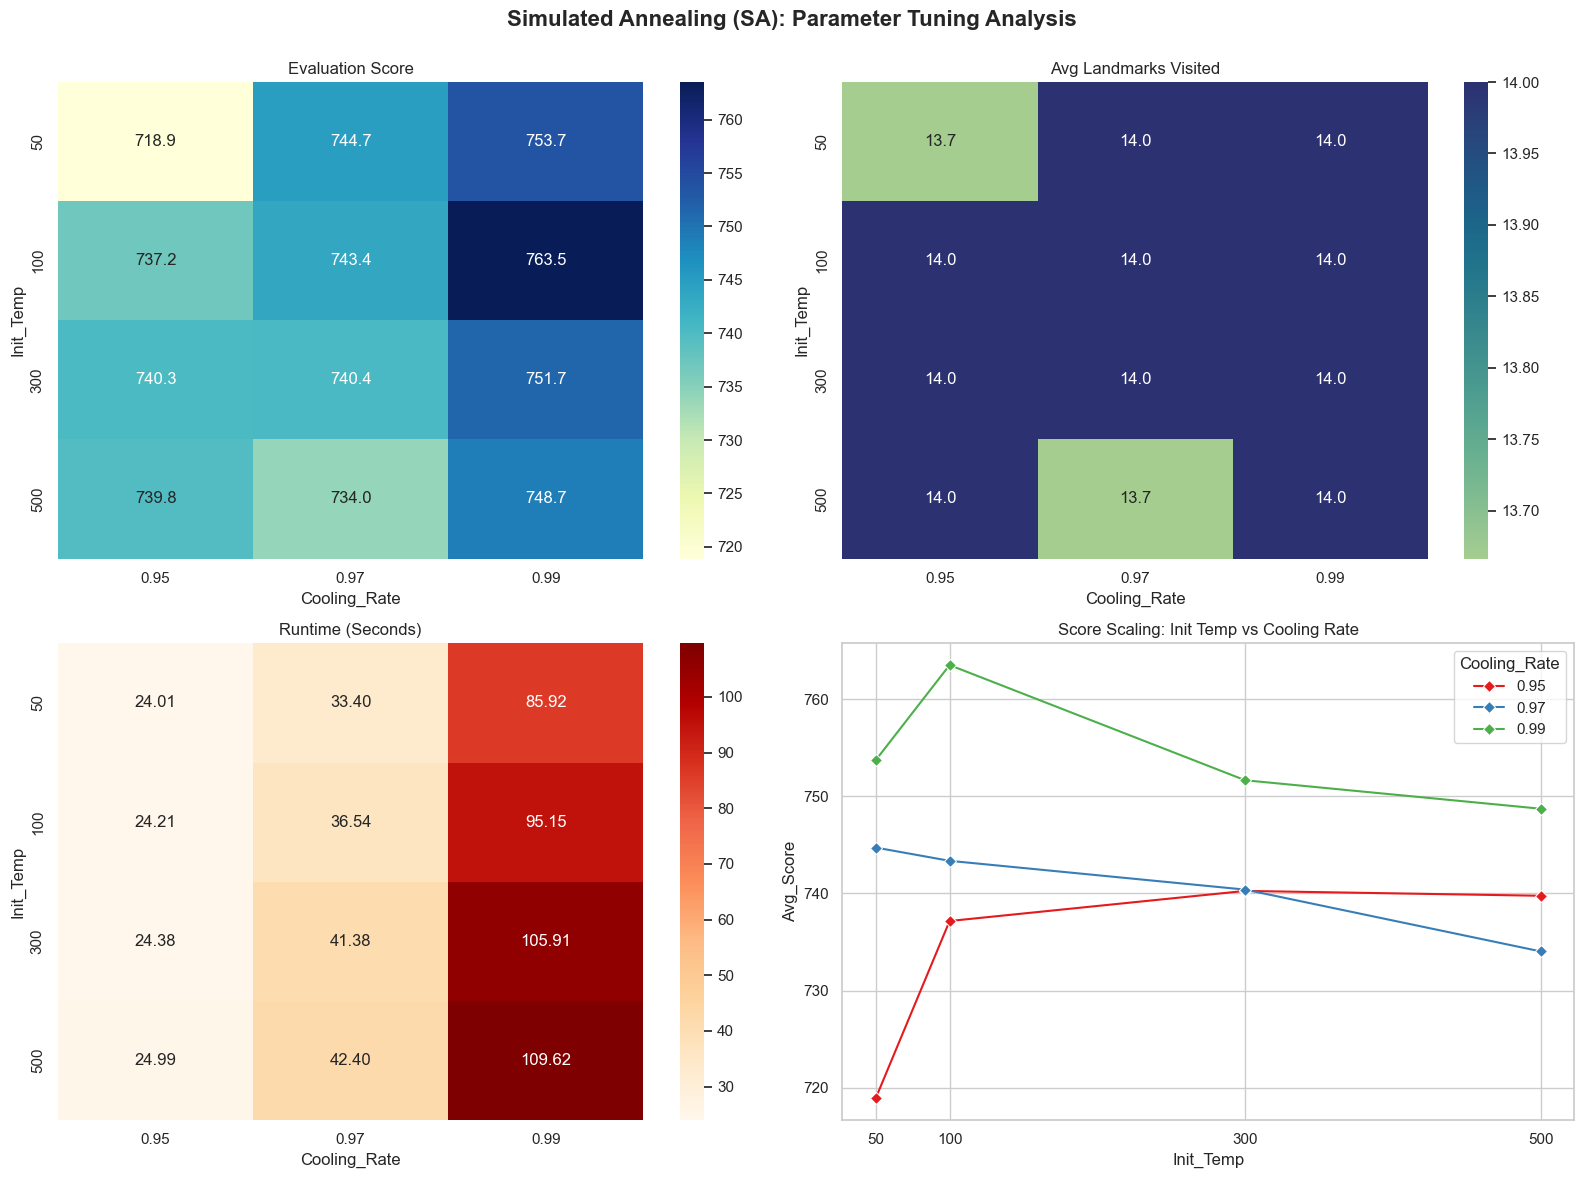

In [40]:
import sys, os, time, random, itertools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add project root to path
try:
    _BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    _BASE_DIR = Path().resolve().parent

if str(_BASE_DIR) not in sys.path:
    sys.path.insert(0, str(_BASE_DIR))


from utils.data_loader import get_landmarks, get_hotels, get_time_matrix

ALGO_NAME = "Simulated Annealing (SA)"

def calculate_unified_score(path, time_matrix):
    if not path: return 0
    total_rating = sum(node.interest_score for node in path if isinstance(node, Landmark))
    total_travel_time = sum(time_matrix[path[i].name][path[i+1].name] for i in range(len(path) - 1))
    return (7 * total_rating) - total_travel_time

def run_sa_notebook_study():
    landmarks = get_landmarks()
    hotels = get_hotels()
    time_matrix = get_time_matrix()
    days = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]
    

    selected_hotel = random.choice(hotels)
    visiting_day = random.choice(days)  
    time_budget_hours = 8.0
    trip_start_time = 9
    
    print("=" * 80)
    print("🌍 TRAVEL ENVIRONMENT & CONSTRAINTS 🌍".center(80))
    print("=" * 80)
    print(f"🏨 Hotel       : {selected_hotel.name}")
    print(f"📅 Day         : {visiting_day.capitalize()}")
    print(f"⏰ Start Time  : {trip_start_time}:00 AM")
    print(f"⏳ Budget      : {time_budget_hours} hours")
    print("=" * 80 + "\n")

    initial_temps = [50, 100, 300, 500]
    cooling_rates = [0.95, 0.97, 0.99]
    max_reheats = [1]
    
    param_results = []
    overall_best_score = -float('inf')
    overall_best_path = []
    
    travel_info = {
        'hotel': selected_hotel, 'Travel_day': visiting_day, 'Travel_Time': time_budget_hours, 
        'type_filter': [], 'time_matrix': time_matrix, 'trip_start_time': trip_start_time
    }
    problem = TravelProblem_LocalSearch(landmarks, travel_info)

    total_combinations = len(initial_temps) * len(cooling_rates) * len(max_reheats)
    print(f"🚀 Executing Grid Search ({total_combinations} configurations)...\n")
    print("-" * 110)
    
    start_global_time = time.time()
    current_iteration = 0

    for temp, cool, reheat in itertools.product(initial_temps, cooling_rates, max_reheats):
        current_iteration += 1
        
        # Professional configuration tracker
        print(f"[{current_iteration:02d}/{total_combinations}] Testing Temp={temp:<4} | Cool={cool:<4} | Reheats={reheat:<2}")
        
        scores, times, visits = [], [], []
        
        for run_id in range(3):
            sa = Simulated_Annealing(problem, initial_temp=temp, cooling_rate=cool, max_reheats=reheat)
            
            start_run_time = time.time()
            best_state = sa.run()
            exec_time = time.time() - start_run_time
            
            full_path = [selected_hotel] + best_state + [selected_hotel]
            score = calculate_unified_score(full_path, time_matrix)
            num_landmarks_visited = len(best_state) 
            
            scores.append(score)
            times.append(exec_time)
            visits.append(num_landmarks_visited)
            
            # Check for a new global best and print detailed info
            if score > overall_best_score:
                overall_best_score = score
                overall_best_path = full_path
                total_rating = sum(node.interest_score for node in full_path if isinstance(node, Landmark))
                
                print(f"   >>> 🌟 NEW GLOBAL BEST! Eval Score: {score:.2f} | Rating: {total_rating:.1f} | Visited: {num_landmarks_visited} | Runtime: {exec_time:.2f}s")
                print(f"   >>> ⚙️  Params Used: Temp={temp}, Cool={cool}, Reheats={reheat}\n")
            
        param_results.append({
            "Init_Temp": temp, "Cooling_Rate": cool, "Max_Reheats": reheat,
            "Avg_Score": sum(scores)/3, "Avg_Time_Sec": sum(times)/3, "Avg_Visited": sum(visits)/3
        })

    print("-" * 110)
    print(f"✅ Grid search completed in {time.time() - start_global_time:.2f} seconds!\n")

    # Best Path Extraction
    best_rating_sum = sum(node.interest_score for node in overall_best_path if isinstance(node, Landmark))
    best_travel_time_min = sum(time_matrix[overall_best_path[i].name][overall_best_path[i+1].name] for i in range(len(overall_best_path) - 1))
    
    print("=" * 80)
    print("🏆 OVERALL BEST ROUTE FOUND 🏆".center(80))
    print("=" * 80)
    print(f"🏅 Final Eval Score   : {overall_best_score:.2f}")
    print(f"⭐ Sum of Ratings     : {best_rating_sum:.2f}")
    print(f"🚗 Total Travel Time  : {best_travel_time_min:.1f} minutes ({best_travel_time_min/60.0:.2f} hours)")
    print(f"📍 Places Visited     : {len(overall_best_path) - 2} landmarks")
    print("-" * 80)
    print("🗺️  STEP-BY-STEP ITINERARY:")
    for i, node in enumerate(overall_best_path):
        if i == 0: print(f"   🛫 START : {node.name} (Hotel)")
        elif i == len(overall_best_path) - 1: print(f"   🛬 END   : {node.name} (Return to Hotel)")
        else: print(f"      -> {node.name} (Rating: {node.interest_score})")
    print("=" * 80 + "\n")

    # Plots
    df_params = pd.DataFrame(param_results)
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"{ALGO_NAME}: Parameter Tuning Analysis", fontsize=16, weight='bold')

    sns.heatmap(df_params.pivot_table(index="Init_Temp", columns="Cooling_Rate", values="Avg_Score", aggfunc='mean'), annot=True, cmap="YlGnBu", fmt=".1f", ax=axes[0, 0]).set_title("Evaluation Score")
    sns.heatmap(df_params.pivot_table(index="Init_Temp", columns="Cooling_Rate", values="Avg_Visited", aggfunc='mean'), annot=True, cmap="crest", fmt=".1f", ax=axes[0, 1]).set_title("Avg Landmarks Visited")
    sns.heatmap(df_params.pivot_table(index="Init_Temp", columns="Cooling_Rate", values="Avg_Time_Sec", aggfunc='mean'), annot=True, cmap="OrRd", fmt=".2f", ax=axes[1, 0]).set_title("Runtime (Seconds)")
    
    # REPLACED PLOT: Shows Score scaling across Temps and Cooling Rates
    sns.lineplot(data=df_params, x="Init_Temp", y="Avg_Score", hue="Cooling_Rate", marker="D", palette="Set1", ax=axes[1, 1]).set_title("Score Scaling: Init Temp vs Cooling Rate")
    axes[1, 1].set_xticks(initial_temps) 

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

if __name__ == "__main__":
    run_sa_notebook_study()

### ***Genetic Algorithms***

explanation and docuementation


PHASE 1 -- Full Factorial: Selection x Crossover x Mutation
         (generations=100, mutation_rate=0.1, pop=100)
  [  1/108]  tournament  | one_point              | insertion       ->  fit= 652.30 time= 7.93h  #lm=13  (0.5s)
  [  2/108]  tournament  | one_point              | swap            ->  fit= 620.00 time= 7.45h  #lm=11  (0.4s)
  [  3/108]  tournament  | one_point              | inversion       ->  fit= 587.10 time= 7.59h  #lm=11  (0.4s)
  [  4/108]  tournament  | one_point              | scramble        ->  fit= 537.80 time= 7.47h  #lm=11  (0.4s)
  [  5/108]  tournament  | one_point              | deletion        ->  fit= 583.70 time= 7.60h  #lm=11  (0.4s)
  [  6/108]  tournament  | one_point              | displacement    ->  fit= 567.00 time= 6.82h  #lm=10  (0.4s)
  [  7/108]  tournament  | two_point              | insertion       ->  fit= 662.80 time= 7.99h  #lm=13  (0.4s)
  [  8/108]  tournament  | two_point              | swap            ->  fit= 555.50 time= 7.06h  #lm

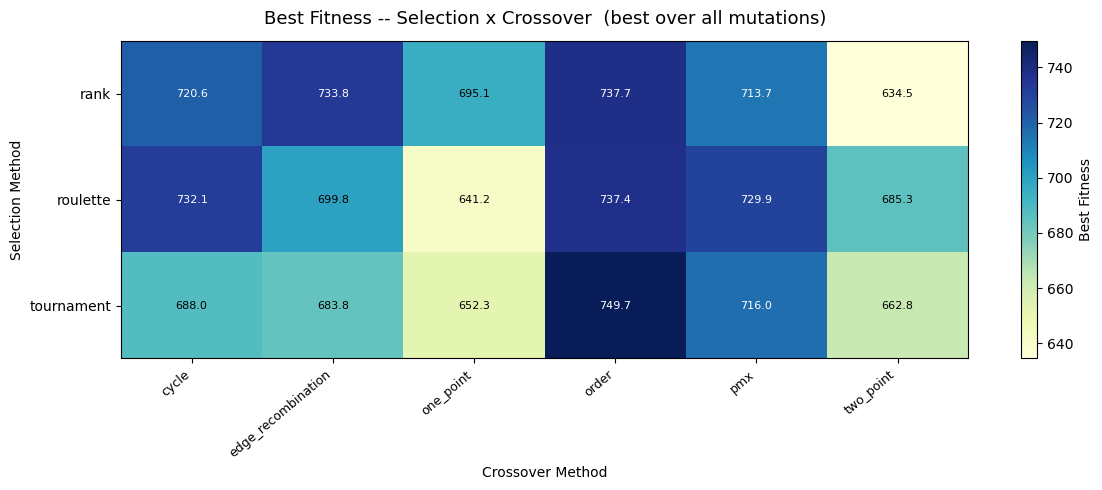

  [OK] c:\Users\ayoub\Desktop\Intro_to_AI_Travel_Project\Tests\GA_test_results\heatmap_sel_cx.png


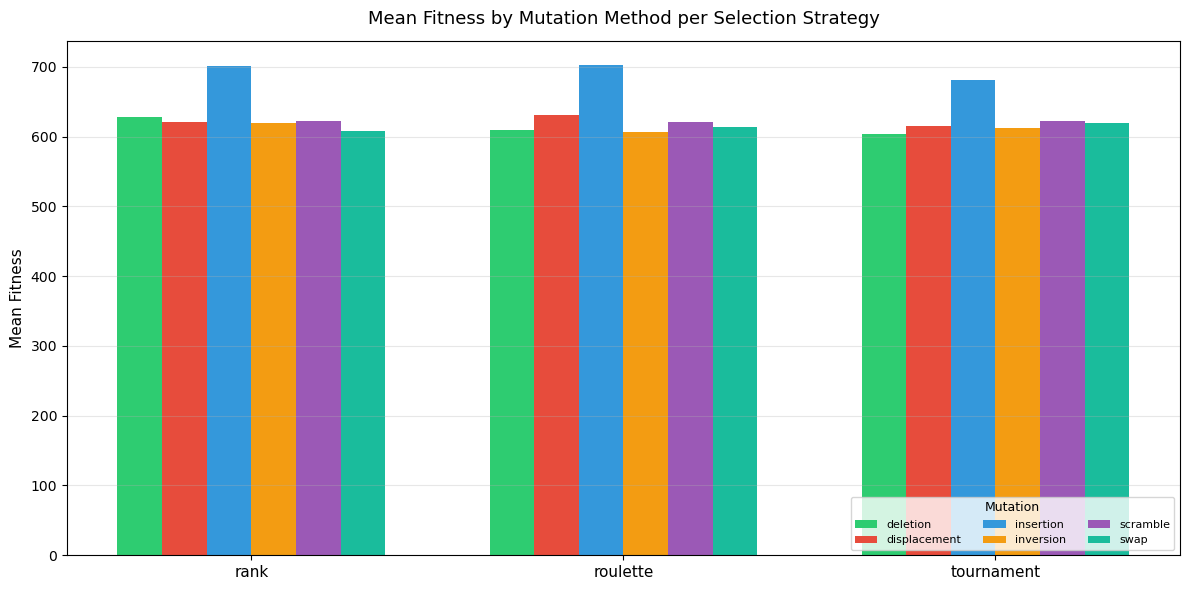

  [OK] c:\Users\ayoub\Desktop\Intro_to_AI_Travel_Project\Tests\GA_test_results\bar_mutation_by_selection.png


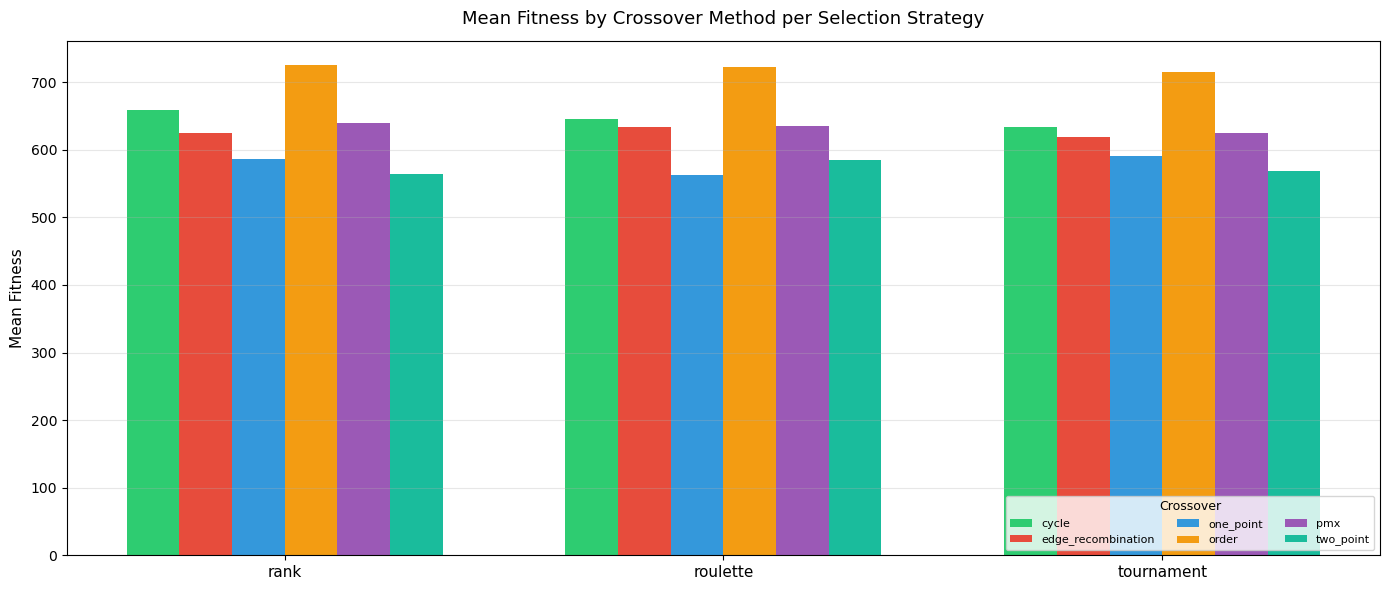

  [OK] c:\Users\ayoub\Desktop\Intro_to_AI_Travel_Project\Tests\GA_test_results\bar_crossover_by_selection.png


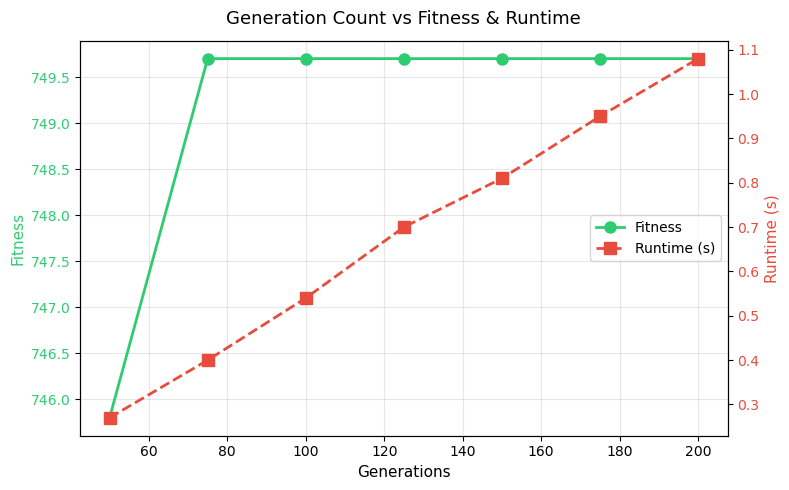

  [OK] c:\Users\ayoub\Desktop\Intro_to_AI_Travel_Project\Tests\GA_test_results\generation_sweep.png


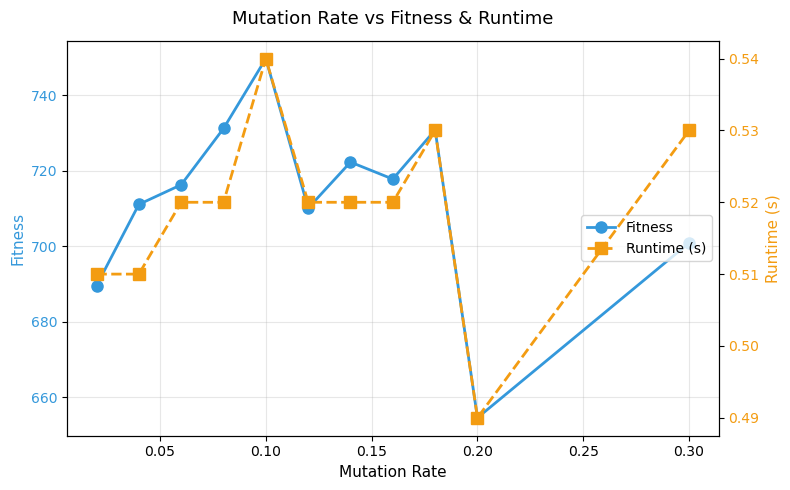

  [OK] c:\Users\ayoub\Desktop\Intro_to_AI_Travel_Project\Tests\GA_test_results\mutation_rate_sweep.png


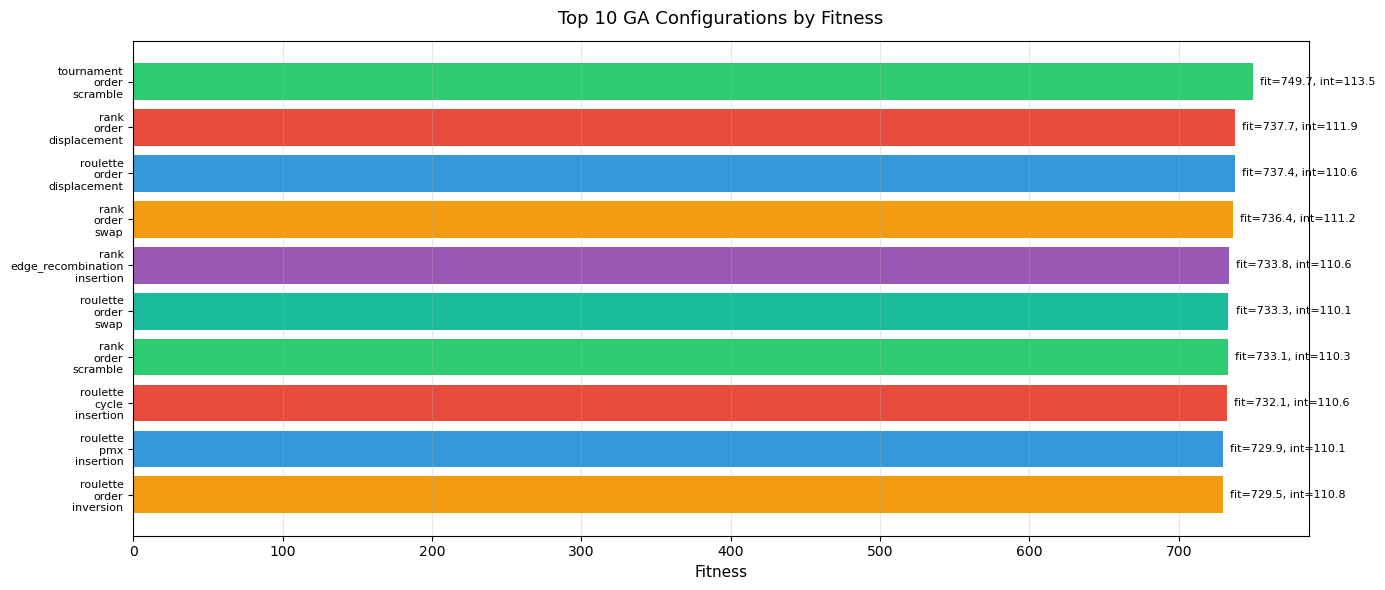

  [OK] c:\Users\ayoub\Desktop\Intro_to_AI_Travel_Project\Tests\GA_test_results\top10_configs.png


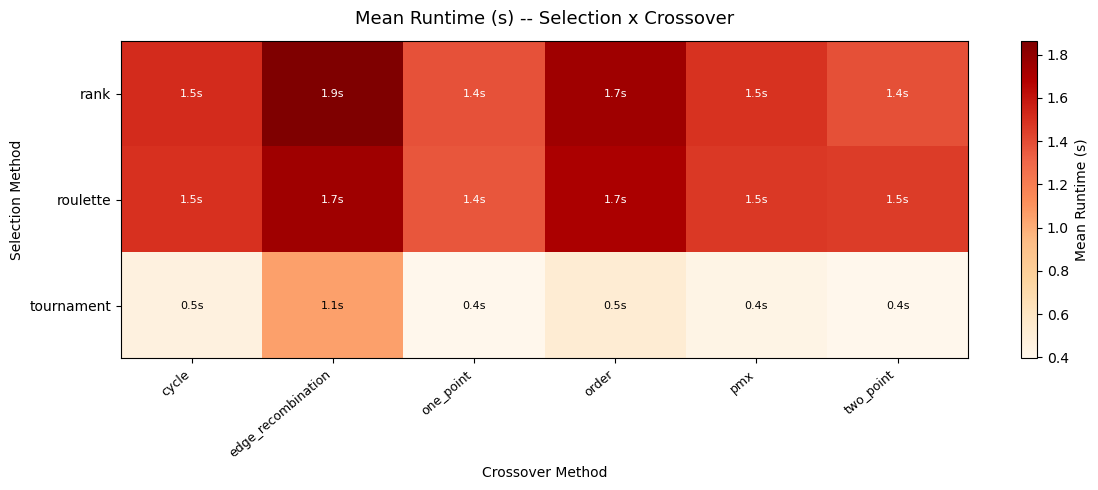

  [OK] c:\Users\ayoub\Desktop\Intro_to_AI_Travel_Project\Tests\GA_test_results\heatmap_runtime.png

SUMMARY -- Top 15 Configurations (by Fitness)
 Selection          Crossover     Mutation  Fitness  Interest  TotalTime_h  NumLandmarks  Runtime_s
tournament              order     scramble    749.7     113.5         7.83            15       0.54
      rank              order displacement    737.7     111.9         7.76            15       1.78
  roulette              order displacement    737.4     110.6         7.70            14       1.69
      rank              order         swap    736.4     111.2         7.70            14       1.73
      rank edge_recombination    insertion    733.8     110.6         7.76            14       2.01
  roulette              order         swap    733.3     110.1         7.71            14       1.72
      rank              order     scramble    733.1     110.3         7.73            14       1.71
  roulette              cycle    insertion    732.1   

In [40]:
#code for the algorithm
"""
GA-test
=========================================================
Tests the GA across multiple:
  Generation counts        (50, 100, 200)
  Mutation rates            (0.05, 0.1, 0.2)
  Selection methods         (tournament, roulette, rank)
  Crossover methods         (one_point, two_point, pmx, order, cycle, edge_recombination)
  Mutation methods           (swap, inversion, scramble, insertion, deletion, displacement)
"""

%matplotlib inline

# ── project imports ──────────────────────────────────────────────────────────
current_dir = os.getcwd()

# ── data loading ─────────────────────────────────────────────────────────────
landmarks = get_landmarks()
hotels     = get_hotels()
time_matrix = get_time_matrix()

# ── problem setup ─────────────────────────────────────────────────────────────
problem = TravelProblem_LocalSearch(
    landmarks,
    travel_information={
        'hotel': hotels[0],
        'time_matrix': time_matrix,
        'Travel_Time': 8,
        'Travel_day': 'fri',
        'type_filter': None,
        'trip_start_time': 9,
    },
)

# ── parameters ───────────────────────────────────────────────────────────
Generation_values   = [50, 75, 100, 125, 150, 175, 200]
Mutation_rates      = [0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2, 0.3]
Selection_methods   = ['tournament', 'roulette', 'rank']
Crossover_methods   = ['one_point', 'two_point', 'pmx', 'order', 'cycle', 'edge_recombination']
Mutation_methods    = ['insertion', 'swap', 'inversion', 'scramble', 'deletion', 'displacement']

POPULATION_SIZE     = 100
SEED                = 42

# ── output directory ─────────────────────────────────────────────────────────
OUTPUT_DIR = os.path.join(current_dir, "Tests", "GA_test_results")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ═════════════════════════════════════════════════════════════════════════════
# 1.  Full factorial test  (selection × crossover × mutation)
#     Using fixed generations=100, mutation_rate=0.1
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 1 -- Full Factorial: Selection x Crossover x Mutation")
print("         (generations=100, mutation_rate=0.1, pop=100)")
print("=" * 70)

rows_factorial = []
total_combos = len(Selection_methods) * len(Crossover_methods) * len(Mutation_methods)
combo_idx = 0

for sel in Selection_methods:
    for cx in Crossover_methods:
        for mut in Mutation_methods:
            combo_idx += 1
            random.seed(SEED)
            ga = Genetic_Algorithm(problem, population_size=POPULATION_SIZE,
                                   generations=100, mutation_rate=0.1)
            t0 = time.time()
            best = ga.evolve(
                selection_method=sel,
                crossover_method=cx,
                mutation_method=mut,
                tournament_size=5,
                neighborhood_selection='linear',
                elitism_rate=0.2,
            )
            elapsed = time.time() - t0
            fitness   = ga.calculate_fitness(best)
            interest = sum(lm.interest_score for lm in best)
            tot_time  = round(ga.calculate_total_time(best), 2)
            n_lm      = len(best)
            rows_factorial.append({
                'Selection': sel,
                'Crossover': cx,
                'Mutation':  mut,
                'Fitness':   round(fitness, 4),
                'Interest':    round(interest, 2),
                'TotalTime_h': tot_time,
                'NumLandmarks': n_lm,
                'Runtime_s':   round(elapsed, 2),
            })
            print(f"  [{combo_idx:3d}/{total_combos}]  {sel:11s} | {cx:22s} | {mut:14s}"
                  f"  ->  fit={fitness:7.2f} "
                  f"time={tot_time:5.2f}h  #lm={n_lm}  ({elapsed:.1f}s)")

df_factorial = pd.DataFrame(rows_factorial)
csv_path = os.path.join(OUTPUT_DIR, "factorial_results.csv")
df_factorial.to_csv(csv_path, index=False)
print(f"\n[OK] Factorial results saved -> {csv_path}")

# ═════════════════════════════════════════════════════════════════════════════
# 2.  Generation count sweep  (best combo from phase 1)
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 2 -- Generation Count Sweep")
print("=" * 70)

best_row = df_factorial.loc[df_factorial['Fitness'].idxmax()]
best_sel, best_cx, best_mut = best_row['Selection'], best_row['Crossover'], best_row['Mutation']
print(f"  Using best combo from Phase 1: {best_sel} / {best_cx} / {best_mut}")

rows_gen = []
for gen in Generation_values:
    random.seed(SEED)
    ga = Genetic_Algorithm(problem, population_size=POPULATION_SIZE,
                           generations=gen, mutation_rate=0.1)
    t0 = time.time()
    best = ga.evolve(
        selection_method=best_sel,
        crossover_method=best_cx,
        mutation_method=best_mut,
        tournament_size=5,
        neighborhood_selection='linear',
        elitism_rate=0.2,
    )
    elapsed = time.time() - t0
    fitness  = ga.calculate_fitness(best)
    interest = sum(lm.interest_score for lm in best)
    tot_time = round(ga.calculate_total_time(best), 2)
    n_lm     = len(best)
    rows_gen.append({
        'Generations': gen,
        'Fitness':     round(fitness, 4),
        'Interest':    round(interest, 2),
        'TotalTime_h': tot_time,
        'NumLandmarks': n_lm,
        'Runtime_s':   round(elapsed, 2),
    })
    print(f"  gen={gen:4d}  ->  fit={fitness:7.2f}"
          f"time={tot_time:5.2f}h  #lm={n_lm}  ({elapsed:.1f}s)")

df_gen = pd.DataFrame(rows_gen)
csv_path = os.path.join(OUTPUT_DIR, "generation_sweep.csv")
df_gen.to_csv(csv_path, index=False)
print(f"  [OK] saved -> {csv_path}")

# ═════════════════════════════════════════════════════════════════════════════
# 3.  Mutation rate sweep
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 3 -- Mutation Rate Sweep")
print("=" * 70)

rows_mr = []
for mr in Mutation_rates:
    random.seed(SEED)
    ga = Genetic_Algorithm(problem, population_size=POPULATION_SIZE,
                           generations=100, mutation_rate=mr)
    t0 = time.time()
    best = ga.evolve(
        selection_method=best_sel,
        crossover_method=best_cx,
        mutation_method=best_mut,
        tournament_size=5,
        neighborhood_selection='linear',
        elitism_rate=0.2,
    )
    elapsed = time.time() - t0
    fitness  = ga.calculate_fitness(best)
    interest = sum(lm.interest_score for lm in best)
    tot_time = round(ga.calculate_total_time(best), 2)
    n_lm     = len(best)
    rows_mr.append({
        'MutationRate': mr,
        'Fitness':      round(fitness, 4),
        'Interest':     round(interest, 2),
        'TotalTime_h':  tot_time,
        'NumLandmarks': n_lm,
        'Runtime_s':    round(elapsed, 2),
    })
    print(f"  mr={mr:.2f}  ->  fit={fitness:7.2f}"
          f"time={tot_time:5.2f}h  #lm={n_lm}  ({elapsed:.1f}s)")

df_mr = pd.DataFrame(rows_mr)
csv_path = os.path.join(OUTPUT_DIR, "mutation_rate_sweep.csv")
df_mr.to_csv(csv_path, index=False)
print(f"  [OK] saved -> {csv_path}")


# ═════════════════════════════════════════════════════════════════════════════
# 4.  PLOTS
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 4 -- Generating Plots")
print("=" * 70)

# ── colour palette ───────────────────────────────────────────────────────────
COLORS = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']

# ---------- Plot 1: Heatmap  — best fitness for each (Selection × Crossover) ----------
fig, ax = plt.subplots(figsize=(12, 5))
pivot = df_factorial.groupby(['Selection', 'Crossover'])['Fitness'].max().unstack()
im = ax.imshow(pivot.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8,
                color='white' if val > pivot.values.mean() else 'black')
fig.colorbar(im, ax=ax, label='Best Fitness')
ax.set_title('Best Fitness -- Selection x Crossover  (best over all mutations)', fontsize=13, pad=12)
ax.set_xlabel('Crossover Method')
ax.set_ylabel('Selection Method')
plt.tight_layout()
path1 = os.path.join(OUTPUT_DIR, "heatmap_sel_cx.png")
fig.savefig(path1, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path1}")

# ---------- Plot 2: Grouped bar — mean fitness by mutation method per selection ----------
fig, ax = plt.subplots(figsize=(12, 6))
grouped = df_factorial.groupby(['Selection', 'Mutation'])['Fitness'].mean().unstack()
x = np.arange(len(grouped.index))
width = 0.12
for i, mut in enumerate(grouped.columns):
    ax.bar(x + i * width, grouped[mut], width, label=mut, color=COLORS[i % len(COLORS)])
ax.set_xticks(x + width * (len(grouped.columns) - 1) / 2)
ax.set_xticklabels(grouped.index, fontsize=11)
ax.set_ylabel('Mean Fitness', fontsize=11)
ax.set_title('Mean Fitness by Mutation Method per Selection Strategy', fontsize=13, pad=12)
ax.legend(title='Mutation', fontsize=8, title_fontsize=9, ncol=3, loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
path2 = os.path.join(OUTPUT_DIR, "bar_mutation_by_selection.png")
fig.savefig(path2, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path2}")

# ---------- Plot 3: Grouped bar — mean fitness by crossover method per selection ----------
fig, ax = plt.subplots(figsize=(14, 6))
grouped_cx = df_factorial.groupby(['Selection', 'Crossover'])['Fitness'].mean().unstack()
x = np.arange(len(grouped_cx.index))
width = 0.12
for i, cx in enumerate(grouped_cx.columns):
    ax.bar(x + i * width, grouped_cx[cx], width, label=cx, color=COLORS[i % len(COLORS)])
ax.set_xticks(x + width * (len(grouped_cx.columns) - 1) / 2)
ax.set_xticklabels(grouped_cx.index, fontsize=11)
ax.set_ylabel('Mean Fitness', fontsize=11)
ax.set_title('Mean Fitness by Crossover Method per Selection Strategy', fontsize=13, pad=12)
ax.legend(title='Crossover', fontsize=8, title_fontsize=9, ncol=3, loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
path3 = os.path.join(OUTPUT_DIR, "bar_crossover_by_selection.png")
fig.savefig(path3, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path3}")

# ---------- Plot 4: Generation sweep — line chart ----------
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(df_gen['Generations'], df_gen['Fitness'], 'o-', color='#2ecc71', linewidth=2, markersize=8, label='Fitness')
ax1.set_xlabel('Generations', fontsize=11)
ax1.set_ylabel('Fitness', color='#2ecc71', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#2ecc71')

ax2 = ax1.twinx()
ax2.plot(df_gen['Generations'], df_gen['Runtime_s'], 's--', color='#e74c3c', linewidth=2, markersize=8, label='Runtime (s)')
ax2.set_ylabel('Runtime (s)', color='#e74c3c', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#e74c3c')

ax1.set_title('Generation Count vs Fitness & Runtime', fontsize=13, pad=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
ax1.grid(alpha=0.3)
plt.tight_layout()
path4 = os.path.join(OUTPUT_DIR, "generation_sweep.png")
fig.savefig(path4, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path4}")

# ---------- Plot 5: Mutation rate sweep — line chart ----------
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(df_mr['MutationRate'], df_mr['Fitness'], 'o-', color='#3498db', linewidth=2, markersize=8, label='Fitness')
ax1.set_xlabel('Mutation Rate', fontsize=11)
ax1.set_ylabel('Fitness', color='#3498db', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#3498db')

ax2 = ax1.twinx()
ax2.plot(df_mr['MutationRate'], df_mr['Runtime_s'], 's--', color='#f39c12', linewidth=2, markersize=8, label='Runtime (s)')
ax2.set_ylabel('Runtime (s)', color='#f39c12', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#f39c12')

ax1.set_title('Mutation Rate vs Fitness & Runtime', fontsize=13, pad=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
ax1.grid(alpha=0.3)
plt.tight_layout()
path5 = os.path.join(OUTPUT_DIR, "mutation_rate_sweep.png")
fig.savefig(path5, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path5}")

# ---------- Plot 6: Top 10 best configurations ----------
top10 = df_factorial.nlargest(10, 'Fitness')
fig, ax = plt.subplots(figsize=(14, 6))
labels_top = [f"{r['Selection']}\n{r['Crossover']}\n{r['Mutation']}" for _, r in top10.iterrows()]
bars = ax.barh(range(len(top10)), top10['Fitness'], color=COLORS * 2)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(labels_top, fontsize=8)
ax.set_xlabel('Fitness', fontsize=11)
ax.set_title('Top 10 GA Configurations by Fitness', fontsize=13, pad=12)
for i, (val, interest) in enumerate(zip(top10['Fitness'], top10['Interest'])):
    ax.text(val + 0.1, i, f'  fit={val:.1f}, int={interest:.1f}', va='center', fontsize=8)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
path6 = os.path.join(OUTPUT_DIR, "top10_configs.png")
fig.savefig(path6, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path6}")

# ---------- Plot 7: Runtime heatmap  — Selection × Crossover ----------
fig, ax = plt.subplots(figsize=(12, 5))
pivot_rt = df_factorial.groupby(['Selection', 'Crossover'])['Runtime_s'].mean().unstack()
im = ax.imshow(pivot_rt.values, cmap='OrRd', aspect='auto')
ax.set_xticks(range(len(pivot_rt.columns)))
ax.set_xticklabels(pivot_rt.columns, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_rt.index)))
ax.set_yticklabels(pivot_rt.index, fontsize=10)
for i in range(len(pivot_rt.index)):
    for j in range(len(pivot_rt.columns)):
        val = pivot_rt.values[i, j]
        ax.text(j, i, f'{val:.1f}s', ha='center', va='center', fontsize=8,
                color='white' if val > pivot_rt.values.mean() else 'black')
fig.colorbar(im, ax=ax, label='Mean Runtime (s)')
ax.set_title('Mean Runtime (s) -- Selection x Crossover', fontsize=13, pad=12)
ax.set_xlabel('Crossover Method')
ax.set_ylabel('Selection Method')
plt.tight_layout()
path7 = os.path.join(OUTPUT_DIR, "heatmap_runtime.png")
fig.savefig(path7, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path7}")


# ═════════════════════════════════════════════════════════════════════════════
# 5.  SUMMARY TABLE  (printed to console)
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("SUMMARY -- Top 15 Configurations (by Fitness)")
print("=" * 70)
top15 = df_factorial.nlargest(15, 'Fitness')
print(top15.to_string(index=False))

print("\n" + "=" * 70)
print("Generation Sweep Results")
print("=" * 70)
print(df_gen.to_string(index=False))

print("\n" + "=" * 70)
print("Mutation Rate Sweep Results")
print("=" * 70)
print(df_mr.to_string(index=False))

print("\n[DONE] All done! Results & plots saved in:", OUTPUT_DIR)


## **Optional Algorithms**

### ***Hill Climbing Algorithms***

explanation and docuementation


PHASE 1 -- Full Test: Strategies x Restarts
  [  1/15]  steepest     | restarts=  1  ->  Interest= 142.80 Fitness= 946.00time=11.98h  #lm=17  (0.5s)
  [  2/15]  steepest     | restarts= 10  ->  Interest= 142.80 Fitness= 946.00time=11.98h  #lm=17  (3.6s)
  [  3/15]  steepest     | restarts= 25  ->  Interest= 146.40 Fitness= 965.80time=11.90h  #lm=18  (8.7s)
  [  4/15]  steepest     | restarts= 50  ->  Interest= 145.80 Fitness= 973.90time=11.95h  #lm=18  (15.7s)
  [  5/15]  steepest     | restarts=100  ->  Interest= 145.80 Fitness= 973.90time=11.95h  #lm=18  (31.0s)
  [  6/15]  stochastic   | restarts=  1  ->  Interest= 139.30 Fitness= 921.50time=11.89h  #lm=17  (1.1s)
  [  7/15]  stochastic   | restarts= 10  ->  Interest= 145.30 Fitness= 966.90time=11.84h  #lm=18  (6.1s)
  [  8/15]  stochastic   | restarts= 25  ->  Interest= 150.30 Fitness= 984.50time=11.79h  #lm=19  (18.4s)
  [  9/15]  stochastic   | restarts= 50  ->  Interest= 152.20 Fitness= 994.30time=11.93h  #lm=19  (39.8s)
  [ 10

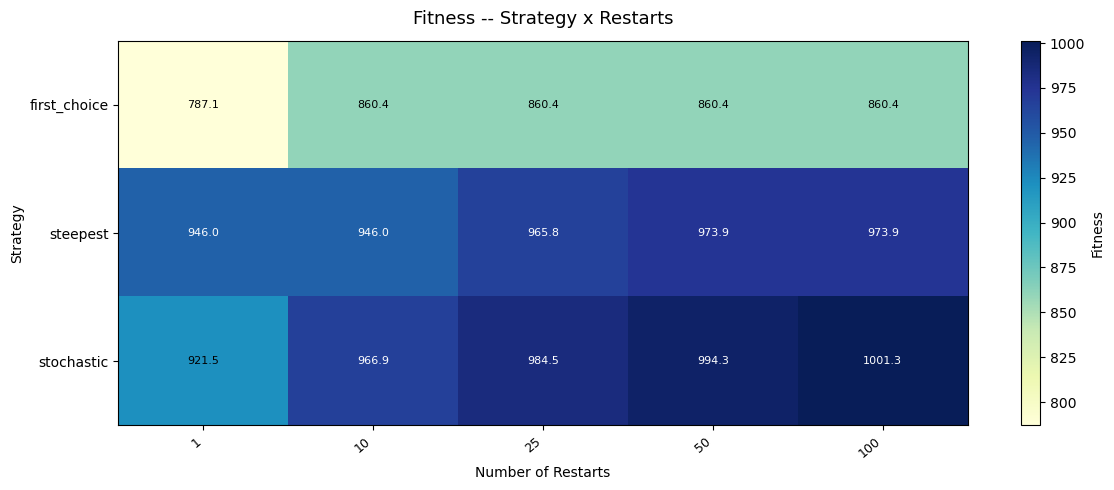

  [OK] c:\Users\ayoub\Desktop\Intro_to_AI_Travel_Project\Tests\hill_climbing_test_results\heatmap_strategy_restarts.png


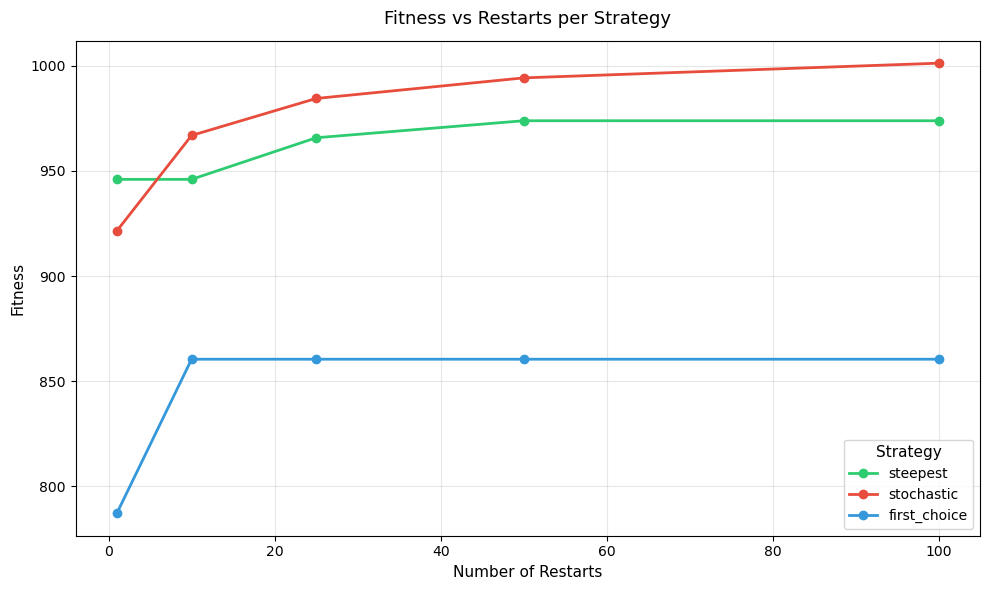

  [OK] c:\Users\ayoub\Desktop\Intro_to_AI_Travel_Project\Tests\hill_climbing_test_results\line_fitness_restarts.png


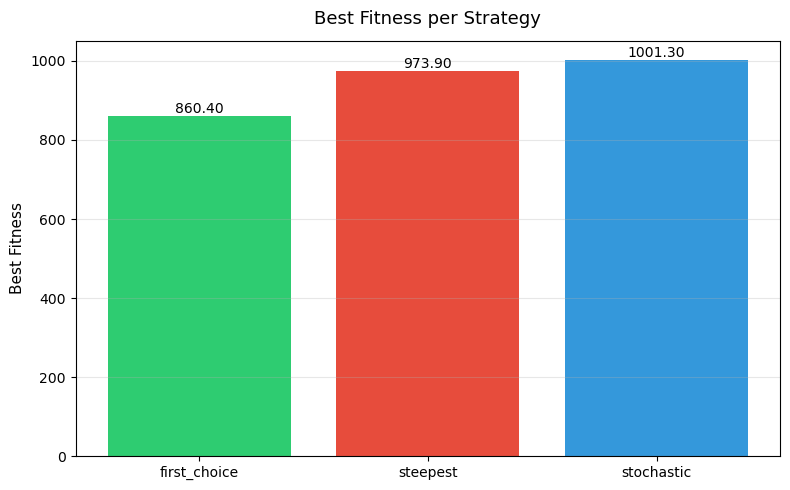

  [OK] c:\Users\ayoub\Desktop\Intro_to_AI_Travel_Project\Tests\hill_climbing_test_results\bar_best_fitness_strategy.png


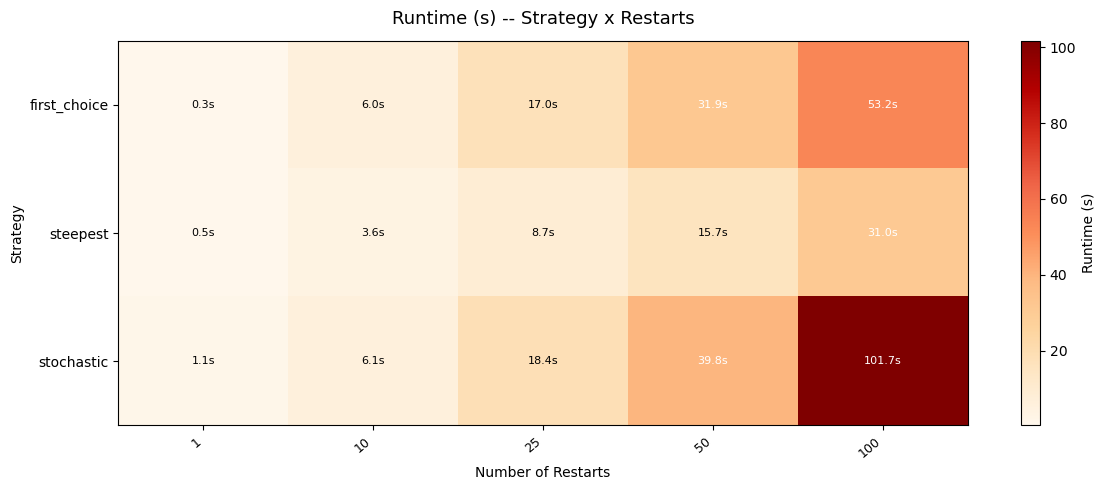

  [OK] c:\Users\ayoub\Desktop\Intro_to_AI_Travel_Project\Tests\hill_climbing_test_results\heatmap_runtime.png


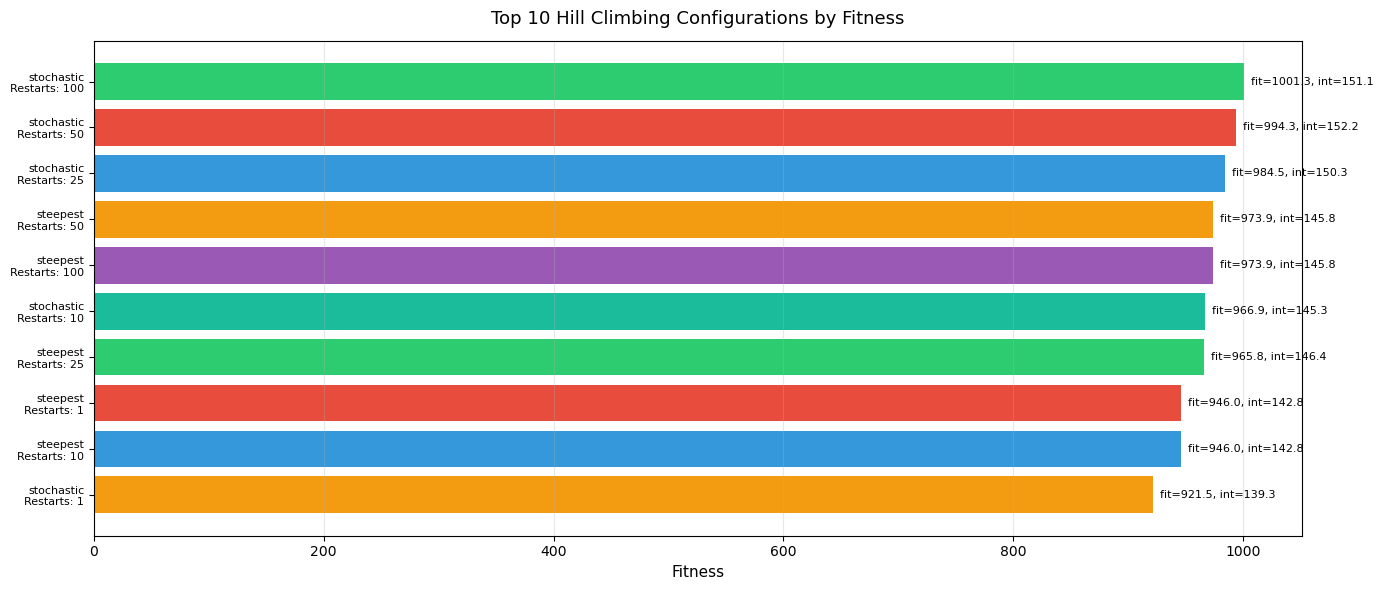

  [OK] c:\Users\ayoub\Desktop\Intro_to_AI_Travel_Project\Tests\hill_climbing_test_results\top10_configs.png

SUMMARY -- Top 15 Configurations (by Fitness)
    Strategy  Restarts  Fitness  Interest  TotalTime_h  NumLandmarks  Runtime_s
  stochastic       100   1001.3     151.1        11.94            19     101.71
  stochastic        50    994.3     152.2        11.93            19      39.81
  stochastic        25    984.5     150.3        11.79            19      18.39
    steepest        50    973.9     145.8        11.95            18      15.72
    steepest       100    973.9     145.8        11.95            18      30.96
  stochastic        10    966.9     145.3        11.84            18       6.10
    steepest        25    965.8     146.4        11.90            18       8.67
    steepest         1    946.0     142.8        11.98            17       0.50
    steepest        10    946.0     142.8        11.98            17       3.64
  stochastic         1    921.5     139.3    

In [41]:
#code for the algorithm
"""
hill_climbing_test
=========================================================
Tests the Hill Climbing algorithm across multiple:
  Base strategies          (steepest, stochastic, first_choice)
  Number of restarts       (1, 10, 25, 50, 100)
"""
%matplotlib inline
# ── project imports ──────────────────────────────────────────────────────────
current_dir = os.getcwd()

# ── data loading ─────────────────────────────────────────────────────────────
landmarks = get_landmarks()
hotels     = get_hotels()
time_matrix = get_time_matrix()

# ── problem setup ─────────────────────────────────────────────────────────────
problem = TravelProblem_LocalSearch(
    landmarks,
    travel_information={
        'hotel': hotels[0],
        'time_matrix': time_matrix,
        'Travel_Time': 12,
        'Travel_day': 'mon',
        'type_filter': None,
        'trip_start_time': 9,
    },
)

# ── parameters ───────────────────────────────────────────────────────────
Base_strategies    = ['steepest', 'stochastic', 'first_choice']
Num_restarts_values = [1, 10, 25, 50, 100]

SEED = 42

# ── output directory ─────────────────────────────────────────────────────────
OUTPUT_DIR = os.path.join(current_dir, "Tests", "hill_climbing_test_results")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ═════════════════════════════════════════════════════════════════════════════
# 1.  Full test: strategies × restarts
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 1 -- Full Test: Strategies x Restarts")
print("=" * 70)

rows_full = []
total_combos = len(Base_strategies) * len(Num_restarts_values)
combo_idx = 0

for strategy in Base_strategies:
    for restarts in Num_restarts_values:
        combo_idx += 1
        random.seed(SEED)
        hc = hill_climbing(problem, num_restarts=restarts, base_strategy=strategy)
        t0 = time.time()
        best = hc.run()
        elapsed = time.time() - t0
        fitness   = hc.evaluate(best.state)
        interest = sum(lm.interest_score for lm in best.state)
        tot_time  = round(hc.calculate_total_time(best.state), 2)
        n_lm      = len(best.state)
        rows_full.append({
            'Strategy': strategy,
            'Restarts': restarts,
            'Fitness':   round(fitness, 4),
            'Interest':    round(interest, 2),
            'TotalTime_h': tot_time,
            'NumLandmarks': n_lm,
            'Runtime_s':   round(elapsed, 2),
        })
        print(f"  [{combo_idx:3d}/{total_combos}]  {strategy:12s} | restarts={restarts:3d}"
              f"  ->  Interest={interest:7.2f} Fitness={fitness:7.2f}"
              f"time={tot_time:5.2f}h  #lm={n_lm}  ({elapsed:.1f}s)")

df_full = pd.DataFrame(rows_full)
csv_path = os.path.join(OUTPUT_DIR, "full_results.csv")
df_full.to_csv(csv_path, index=False)
print(f"\n[OK] Full results saved -> {csv_path}")

# ═════════════════════════════════════════════════════════════════════════════
# 2.  Restarts sweep for each strategy
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 2 -- Restarts Sweep per Strategy")
print("=" * 70)

rows_restart = []
for strategy in Base_strategies:
    for restarts in Num_restarts_values:
        random.seed(SEED)
        hc = hill_climbing(problem, num_restarts=restarts, base_strategy=strategy)
        t0 = time.time()
        best = hc.run()
        elapsed = time.time() - t0
        fitness  = hc.evaluate(best.state)
        interest = sum(lm.interest_score for lm in best.state)
        tot_time = round(hc.calculate_total_time(best.state), 2)
        n_lm     = len(best.state)
        rows_restart.append({
            'Strategy': strategy,
            'Restarts': restarts,
            'Fitness':     round(fitness, 4),
            'Interest':    round(interest, 2),
            'TotalTime_h': tot_time,
            'NumLandmarks': n_lm,
            'Runtime_s':   round(elapsed, 2),
        })
    print(f"  [OK] {strategy} restarts sweep completed")

df_restart = pd.DataFrame(rows_restart)
csv_path = os.path.join(OUTPUT_DIR, "restarts_sweep.csv")
df_restart.to_csv(csv_path, index=False)
print(f"  [OK] saved -> {csv_path}")

# ═════════════════════════════════════════════════════════════════════════════
# 3.  PLOTS
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 3 -- Generating Plots")
print("=" * 70)

# ── colour palette ───────────────────────────────────────────────────────────
COLORS = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']

# ---------- Plot 1: Heatmap — fitness for each (Strategy × Restarts) ----------
fig, ax = plt.subplots(figsize=(12, 5))
pivot = df_full.pivot(index='Strategy', columns='Restarts', values='Fitness')
im = ax.imshow(pivot.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8,
                color='white' if val > pivot.values.mean() else 'black')
fig.colorbar(im, ax=ax, label='Fitness')
ax.set_title('Fitness -- Strategy x Restarts', fontsize=13, pad=12)
ax.set_xlabel('Number of Restarts')
ax.set_ylabel('Strategy')
plt.tight_layout()
path1 = os.path.join(OUTPUT_DIR, "heatmap_strategy_restarts.png")
fig.savefig(path1, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path1}")

# ---------- Plot 2: Line chart — fitness vs restarts per strategy ----------
fig, ax = plt.subplots(figsize=(10, 6))
for i, strategy in enumerate(Base_strategies):
    subset = df_restart[df_restart['Strategy'] == strategy]
    ax.plot(subset['Restarts'], subset['Fitness'], 'o-', color=COLORS[i % len(COLORS)], linewidth=2, markersize=6, label=strategy)
ax.set_xlabel('Number of Restarts', fontsize=11)
ax.set_ylabel('Fitness', fontsize=11)
ax.set_title('Fitness vs Restarts per Strategy', fontsize=13, pad=12)
ax.legend(title='Strategy', fontsize=10, title_fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
path2 = os.path.join(OUTPUT_DIR, "line_fitness_restarts.png")
fig.savefig(path2, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path2}")

# ---------- Plot 3: Bar chart — best fitness per strategy ----------
best_per_strategy = df_full.groupby('Strategy')['Fitness'].max()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(best_per_strategy.index, best_per_strategy.values, color=COLORS[:len(Base_strategies)])
ax.set_ylabel('Best Fitness', fontsize=11)
ax.set_title('Best Fitness per Strategy', fontsize=13, pad=12)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, best_per_strategy.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
path3 = os.path.join(OUTPUT_DIR, "bar_best_fitness_strategy.png")
fig.savefig(path3, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path3}")

# ---------- Plot 4: Runtime heatmap — Strategy × Restarts ----------
fig, ax = plt.subplots(figsize=(12, 5))
pivot_rt = df_full.pivot(index='Strategy', columns='Restarts', values='Runtime_s')
im = ax.imshow(pivot_rt.values, cmap='OrRd', aspect='auto')
ax.set_xticks(range(len(pivot_rt.columns)))
ax.set_xticklabels(pivot_rt.columns, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_rt.index)))
ax.set_yticklabels(pivot_rt.index, fontsize=10)
for i in range(len(pivot_rt.index)):
    for j in range(len(pivot_rt.columns)):
        val = pivot_rt.values[i, j]
        ax.text(j, i, f'{val:.1f}s', ha='center', va='center', fontsize=8,
                color='white' if val > pivot_rt.values.mean() else 'black')
fig.colorbar(im, ax=ax, label='Runtime (s)')
ax.set_title('Runtime (s) -- Strategy x Restarts', fontsize=13, pad=12)
ax.set_xlabel('Number of Restarts')
ax.set_ylabel('Strategy')
plt.tight_layout()
path4 = os.path.join(OUTPUT_DIR, "heatmap_runtime.png")
fig.savefig(path4, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path4}")

# ---------- Plot 5: Top 10 configurations ----------
top10 = df_full.nlargest(10, 'Fitness')
fig, ax = plt.subplots(figsize=(14, 6))
labels_top = [f"{r['Strategy']}\nRestarts: {r['Restarts']}" for _, r in top10.iterrows()]
bars = ax.barh(range(len(top10)), top10['Fitness'], color=COLORS * 2)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(labels_top, fontsize=8)
ax.set_xlabel('Fitness', fontsize=11)
ax.set_title('Top 10 Hill Climbing Configurations by Fitness', fontsize=13, pad=12)
for i, (val, interest) in enumerate(zip(top10['Fitness'], top10['Interest'])):
    ax.text(val + 0.1, i, f'  fit={val:.1f}, int={interest:.1f}', va='center', fontsize=8)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
path5 = os.path.join(OUTPUT_DIR, "top10_configs.png")
fig.savefig(path5, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path5}")

# ═════════════════════════════════════════════════════════════════════════════
# 4.  SUMMARY TABLE  (printed to console)
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("SUMMARY -- Top 15 Configurations (by Fitness)")
print("=" * 70)
top15 = df_full.nlargest(15, 'Fitness')
print(top15.to_string(index=False))

print("\n" + "=" * 70)
print("Restarts Sweep Results")
print("=" * 70)
print(df_restart.to_string(index=False))

print("\n[DONE] All done! Results & plots saved in:", OUTPUT_DIR)


### ***Ant Colony System Test***

explanation and docuementation

                      🌍 TRAVEL ENVIRONMENT & CONSTRAINTS 🌍                      
🏨 Hotel       : EL ROUBIYA hotel
📅 Day         : Tue
⏰ Start Time  : 9:00 AM
⏳ Budget      : 8.0 hours

🚀 Executing Grid Search (162 configurations)...

--------------------------------------------------------------------------------------------------------------
[01/162] Testing a=0.2 | b=2.5 | p=0.05 | Ants=40 | Gens=80 
   >>> 🌟 NEW GLOBAL BEST! Eval Score: 634.80 | Rating: 101.3 | Visited: 13 | Runtime: 6.49s
   >>> ⚙️  Params Used: a=0.2, b=2.5, p=0.05, Ants=40, Gens=80

   >>> 🌟 NEW GLOBAL BEST! Eval Score: 636.90 | Rating: 102.3 | Visited: 13 | Runtime: 5.89s
   >>> ⚙️  Params Used: a=0.2, b=2.5, p=0.05, Ants=40, Gens=80

[02/162] Testing a=0.2 | b=2.5 | p=0.05 | Ants=40 | Gens=100
   >>> 🌟 NEW GLOBAL BEST! Eval Score: 654.00 | Rating: 103.3 | Visited: 13 | Runtime: 6.80s
   >>> ⚙️  Params Used: a=0.2, b=2.5, p=0.05, Ants=40, Gens=100

[03/162] Testing a=0.2 | b=2.5 | p=0.05 | Ants=40 | Gens=120
[04

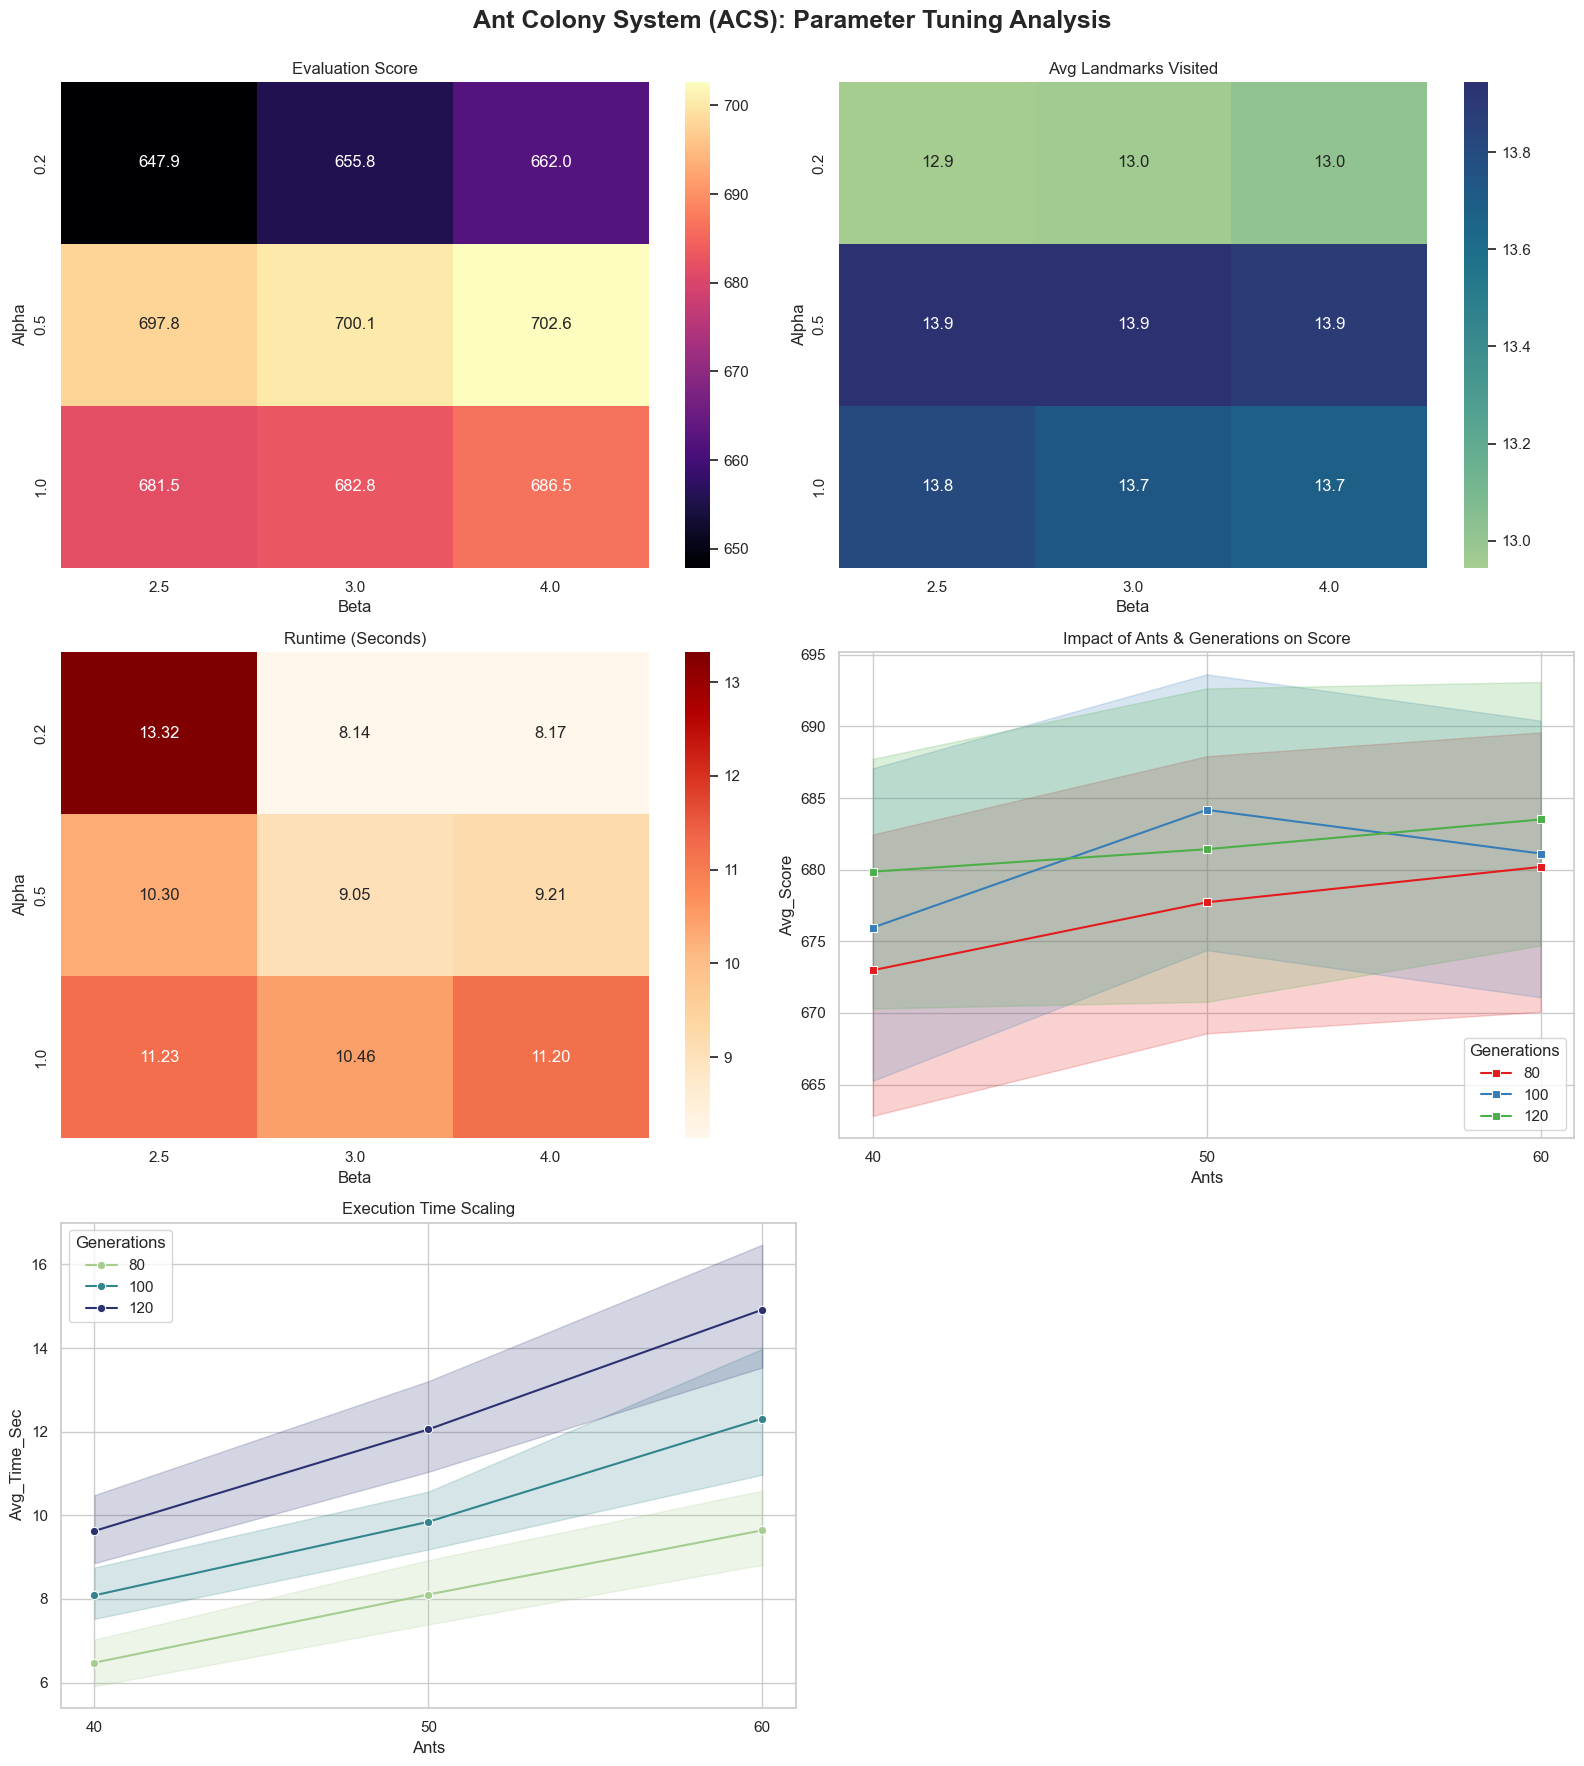

In [38]:

# Add project root to path
try:
    _BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    _BASE_DIR = Path().resolve().parent 

if str(_BASE_DIR) not in sys.path:
    sys.path.insert(0, str(_BASE_DIR))


from utils.data_loader import get_landmarks, get_hotels, get_time_matrix

ALGO_NAME = "Ant Colony System (ACS)"

def calculate_unified_score(path, time_matrix):
    if not path: return 0
    total_rating = sum(node.interest_score for node in path if isinstance(node, Landmark))
    total_travel_time = sum(time_matrix[path[i].name][path[i+1].name] for i in range(len(path) - 1))
    return (7 * total_rating) - total_travel_time

def run_acs_notebook_study():
    landmarks = get_landmarks()
    hotels = get_hotels()
    time_matrix = get_time_matrix()
    days = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]


    selected_hotel = random.choice(hotels)
    visiting_day = random.choice(days)
    time_budget_hours = 8.0
    trip_start_time = 9

    print("=" * 80)
    print("🌍 TRAVEL ENVIRONMENT & CONSTRAINTS 🌍".center(80))
    print("=" * 80)
    print(f"🏨 Hotel       : {selected_hotel.name}")
    print(f"📅 Day         : {visiting_day.capitalize()}")
    print(f"⏰ Start Time  : {trip_start_time}:00 AM")
    print(f"⏳ Budget      : {time_budget_hours} hours")
    print("=" * 80 + "\n")

    alphas = [0.2 ,0.5, 1.0]       
    betas = [2.5 , 3.0, 4.0]        
    rhos = [0.05, 0.3]         
    num_ants_list = [40, 50, 60]       
    generations_list = [80, 100, 120]
    
    param_results = []
    overall_best_score = -float('inf')
    overall_best_path = [] 
    
    total_combinations = len(alphas) * len(betas) * len(rhos) * len(num_ants_list) * len(generations_list)
    print(f"🚀 Executing Grid Search ({total_combinations} configurations)...\n")
    print("-" * 110)
    
    start_global_time = time.time()
    current_iteration = 0

    for alpha, beta, rho, ants, gens in itertools.product(alphas, betas, rhos, num_ants_list, generations_list):
        current_iteration += 1
        
        # Professional configuration tracker
        print(f"[{current_iteration:02d}/{total_combinations}] Testing a={alpha:<3} | b={beta:<3} | p={rho:<4} | Ants={ants:<2} | Gens={gens:<3}")
        
        scores, times, visits = [], [], []
        
        for run_id in range(3):
            env = ACSEnvironment(
                hotel=selected_hotel, 
                landmarks=landmarks, 
                time_matrix=time_matrix, 
                time_budget_hours=time_budget_hours, 
                trip_start_time_hours=trip_start_time, 
                visiting_day=visiting_day
            )
            acs = AntColonySystem(env, num_ants=ants, generations=gens, alpha=alpha, beta=beta, rho=rho)
            
            start_t = time.time()
            best_path, _ = acs.solve()  
            exec_time = time.time() - start_t
            
            score = calculate_unified_score(best_path, time_matrix)
            num_landmarks_visited = len([node for node in best_path if isinstance(node, Landmark)])
            
            scores.append(score)
            times.append(exec_time)
            visits.append(num_landmarks_visited)
            
            # Check for a new global best and print detailed info
            if score > overall_best_score:
                overall_best_score = score
                overall_best_path = best_path
                total_rating = sum(node.interest_score for node in best_path if isinstance(node, Landmark))
                
                print(f"   >>> 🌟 NEW GLOBAL BEST! Eval Score: {score:.2f} | Rating: {total_rating:.1f} | Visited: {num_landmarks_visited} | Runtime: {exec_time:.2f}s")
                print(f"   >>> ⚙️  Params Used: a={alpha}, b={beta}, p={rho}, Ants={ants}, Gens={gens}\n")
            
        param_results.append({
            "Alpha": alpha, "Beta": beta, "Rho": rho, "Ants": ants, "Generations": gens,
            "Avg_Score": sum(scores)/3, "Avg_Time_Sec": sum(times)/3, "Avg_Visited": sum(visits)/3
        })

    print("-" * 110)
    print(f"✅ Grid search completed in {time.time() - start_global_time:.2f} seconds!\n")

    # Best Path Extraction
    best_rating_sum = sum(node.interest_score for node in overall_best_path if isinstance(node, Landmark))
    best_travel_time_min = sum(time_matrix[overall_best_path[i].name][overall_best_path[i+1].name] for i in range(len(overall_best_path) - 1))

    print("=" * 80)
    print("🏆 OVERALL BEST ROUTE FOUND 🏆".center(80))
    print("=" * 80)
    print(f"🏅 Final Eval Score   : {overall_best_score:.2f}")
    print(f"⭐ Sum of Ratings     : {best_rating_sum:.2f}")
    print(f"🚗 Total Travel Time  : {best_travel_time_min:.1f} minutes ({best_travel_time_min/60.0:.2f} hours)")
    print(f"📍 Places Visited     : {len([n for n in overall_best_path if isinstance(n, Landmark)])} landmarks")
    print("-" * 80)
    print("🗺️  STEP-BY-STEP ITINERARY:")
    for i, node in enumerate(overall_best_path):
        if i == 0: print(f"   🛫 START : {node.name} (Hotel)")
        elif i == len(overall_best_path) - 1: print(f"   🛬 END   : {node.name} (Return to Hotel)")
        else: print(f"      -> {node.name} (Rating: {node.interest_score})")
    print("=" * 80 + "\n")

    # Plots
    df_params = pd.DataFrame(param_results)
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    fig.suptitle(f"{ALGO_NAME}: Parameter Tuning Analysis", fontsize=18, weight='bold')

    sns.heatmap(df_params.pivot_table(index="Alpha", columns="Beta", values="Avg_Score", aggfunc='mean'), annot=True, cmap="magma", fmt=".1f", ax=axes[0, 0]).set_title("Evaluation Score")
    sns.heatmap(df_params.pivot_table(index="Alpha", columns="Beta", values="Avg_Visited", aggfunc='mean'), annot=True, cmap="crest", fmt=".1f", ax=axes[0, 1]).set_title("Avg Landmarks Visited")
    sns.heatmap(df_params.pivot_table(index="Alpha", columns="Beta", values="Avg_Time_Sec", aggfunc='mean'), annot=True, cmap="OrRd", fmt=".2f", ax=axes[1, 0]).set_title("Runtime (Seconds)")
    sns.lineplot(data=df_params, x="Ants", y="Avg_Score", hue="Generations", marker="s", palette="Set1", ax=axes[1, 1]).set_title("Impact of Ants & Generations on Score")
    axes[1, 1].set_xticks(num_ants_list) 
    sns.lineplot(data=df_params, x="Ants", y="Avg_Time_Sec", hue="Generations", marker="o", palette="crest", ax=axes[2, 0]).set_title("Execution Time Scaling")
    axes[2, 0].set_xticks(num_ants_list)

    fig.delaxes(axes[2, 1])
    plt.tight_layout()
    plt.subplots_adjust(top=0.94) 
    plt.show()

if __name__ == "__main__":
    run_acs_notebook_study()

### ***ACS with SA Algorithms***

explanation and docuementation

                  🌍 Hybrid-ACS-SA ENVIRONMENT & CONSTRAINTS 🌍                   
🏨 Hotel       : Hôstel NR
📅 Day         : Fri
⏰ Start Time  : 9:00 AM
⏳ Budget      : 8.0 hours

🚀 Executing Hybrid Grid Search (9 configurations)...

📌 Locked Params: a=0.5, b=3.0, p=0.3 | SA Logic: Embedded
--------------------------------------------------------------------------------------------------------------
[01/9] Testing Ants=30 | Gens=80 
   >>> 🌟 NEW GLOBAL BEST! Eval Score: 695.40 | Rating: 109.9 | Visited: 14 | Runtime: 8.98s
   >>> ⚙️  Params Used: Ants=30, Gens=80 (Hybrid-SA Enabled)

   >>> 🌟 NEW GLOBAL BEST! Eval Score: 697.10 | Rating: 109.3 | Visited: 14 | Runtime: 6.89s
   >>> ⚙️  Params Used: Ants=30, Gens=80 (Hybrid-SA Enabled)

[02/9] Testing Ants=30 | Gens=100
   >>> 🌟 NEW GLOBAL BEST! Eval Score: 706.50 | Rating: 110.9 | Visited: 14 | Runtime: 6.89s
   >>> ⚙️  Params Used: Ants=30, Gens=100 (Hybrid-SA Enabled)

[03/9] Testing Ants=30 | Gens=120
   >>> 🌟 NEW GLOBAL BEST! Eval Sco

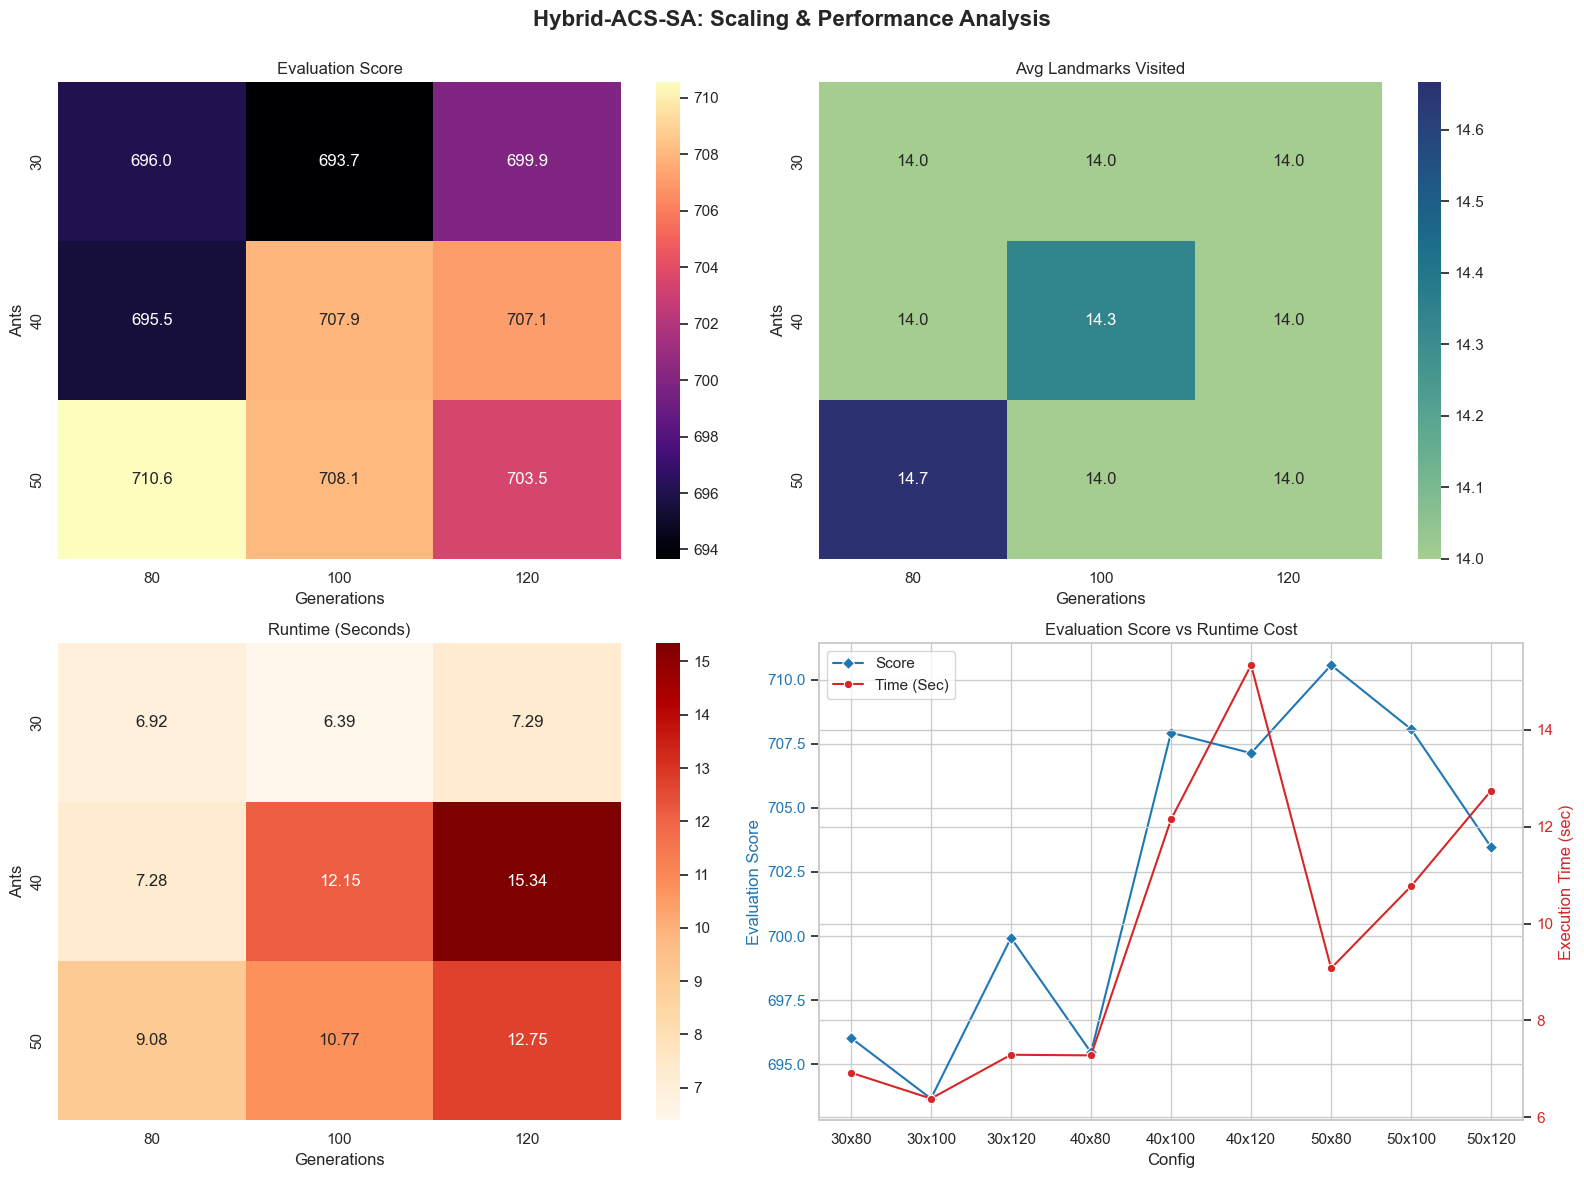

In [34]:

# Add project root to path
try:
    _BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    _BASE_DIR = Path().resolve().parent

if str(_BASE_DIR) not in sys.path:
    sys.path.insert(0, str(_BASE_DIR))


from utils.data_loader import get_landmarks, get_hotels, get_time_matrix

ALGO_NAME = "Hybrid-ACS-SA"

# Unified Score Function
def calculate_unified_score(path, time_matrix):
    if not path: return 0
    total_rating = sum(node.interest_score for node in path if isinstance(node, Landmark))
    total_travel_time = sum(time_matrix[path[i].name][path[i+1].name] for i in range(len(path) - 1))
    return (7 * total_rating) - total_travel_time

def run_hybrid_notebook_study():
    landmarks = get_landmarks()
    hotels = get_hotels()
    time_matrix = get_time_matrix()
    days = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]

    selected_hotel = random.choice(hotels)
    visiting_day = random.choice(days)
    time_budget_hours = 8.0
    trip_start_time = 9

    print("=" * 80)
    print(f"🌍 {ALGO_NAME} ENVIRONMENT & CONSTRAINTS 🌍".center(80))
    print("=" * 80)
    print(f"🏨 Hotel       : {selected_hotel.name}")
    print(f"📅 Day         : {visiting_day.capitalize()}")
    print(f"⏰ Start Time  : {trip_start_time}:00 AM")
    print(f"⏳ Budget      : {time_budget_hours} hours")
    print("=" * 80 + "\n")

    # Parameter Ranges: Focusing heavily on the scaling of Ants and Generations
    num_ants_list = [30, 40, 50]
    generations_list = [80, 100, 120]
    
    # Locking best standard ACS variables found previously
    best_alpha, best_beta, best_rho = 0.5, 3.0, 0.3
    #1.5 3.0 0.05
    
    param_results = []
    overall_best_score = -float('inf')
    overall_best_path = []
    
    total_combinations = len(num_ants_list) * len(generations_list)
    print(f"🚀 Executing Hybrid Grid Search ({total_combinations} configurations)...\n")
    print(f"📌 Locked Params: a={best_alpha}, b={best_beta}, p={best_rho} | SA Logic: Embedded")
    print("-" * 110)
    
    start_global_time = time.time()
    current_iteration = 0

    for ants, gens in itertools.product(num_ants_list, generations_list):
        current_iteration += 1
        
        # Professional configuration tracker
        print(f"[{current_iteration:02d}/{total_combinations}] Testing Ants={ants:<2} | Gens={gens:<3}")
        
        scores, times, visits = [], [], []
        
        for run_id in range(3):
            env = ACSEnvironment(
                hotel=selected_hotel, 
                landmarks=landmarks, 
                time_matrix=time_matrix, 
                time_budget_hours=time_budget_hours, 
                trip_start_time_hours=trip_start_time, 
                visiting_day=visiting_day
            )
            
            # Initialize with hybrid_sa=True
            acs_hybrid = AntColonySystem(
                env, 
                num_ants=ants, 
                generations=gens, 
                alpha=best_alpha, 
                beta=best_beta, 
                rho=best_rho, 
                hybrid_sa=True
            )
            
            start_t = time.time()
            best_path, _ = acs_hybrid.solve() 
            exec_time = time.time() - start_t
            
            score = calculate_unified_score(best_path, time_matrix)
            num_landmarks_visited = len([node for node in best_path if isinstance(node, Landmark)])
            
            scores.append(score)
            times.append(exec_time)
            visits.append(num_landmarks_visited)
            
            # Check for a new global best and print detailed info
            if score > overall_best_score:
                overall_best_score = score
                overall_best_path = best_path
                total_rating = sum(node.interest_score for node in best_path if isinstance(node, Landmark))
                
                print(f"   >>> 🌟 NEW GLOBAL BEST! Eval Score: {score:.2f} | Rating: {total_rating:.1f} | Visited: {num_landmarks_visited} | Runtime: {exec_time:.2f}s")
                print(f"   >>> ⚙️  Params Used: Ants={ants}, Gens={gens} (Hybrid-SA Enabled)\n")
            
        param_results.append({
            "Ants": ants, "Generations": gens,
            "Avg_Score": sum(scores)/3, "Avg_Time_Sec": sum(times)/3, "Avg_Visited": sum(visits)/3
        })

    print("-" * 110)
    print(f"✅ Grid search completed in {time.time() - start_global_time:.2f} seconds!\n")

    # Best Path Extraction
    best_rating_sum = sum(node.interest_score for node in overall_best_path if isinstance(node, Landmark))
    best_travel_time_min = sum(time_matrix[overall_best_path[i].name][overall_best_path[i+1].name] for i in range(len(overall_best_path) - 1))

    print("=" * 80)
    print("🏆 OVERALL BEST ROUTE FOUND 🏆".center(80))
    print("=" * 80)
    print(f"🏅 Final Eval Score   : {overall_best_score:.2f}")
    print(f"⭐ Sum of Ratings     : {best_rating_sum:.2f}")
    print(f"🚗 Total Travel Time  : {best_travel_time_min:.1f} minutes ({best_travel_time_min/60.0:.2f} hours)")
    print(f"📍 Places Visited     : {len([n for n in overall_best_path if isinstance(n, Landmark)])} landmarks")
    print("-" * 80)
    print("🗺️  STEP-BY-STEP ITINERARY:")
    for i, node in enumerate(overall_best_path):
        if i == 0: print(f"   🛫 START : {node.name} (Hotel)")
        elif i == len(overall_best_path) - 1: print(f"   🛬 END   : {node.name} (Return to Hotel)")
        else: print(f"      -> {node.name} (Rating: {node.interest_score})")
    print("=" * 80 + "\n")

    # ---------------------------------------------------------
    # Professional 2x2 Plots directly in Output
    # ---------------------------------------------------------
    df_params = pd.DataFrame(param_results)
    df_params['Config'] = df_params['Ants'].astype(str) + "x" + df_params['Generations'].astype(str)
    
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"{ALGO_NAME}: Scaling & Performance Analysis", fontsize=16, weight='bold')

    # Top Left: Evaluation Score
    sns.heatmap(df_params.pivot_table(index="Ants", columns="Generations", values="Avg_Score", aggfunc='mean'), 
                annot=True, cmap="magma", fmt=".1f", ax=axes[0, 0]).set_title("Evaluation Score")
    
    # Top Right: Avg Landmarks Visited
    sns.heatmap(df_params.pivot_table(index="Ants", columns="Generations", values="Avg_Visited", aggfunc='mean'), 
                annot=True, cmap="crest", fmt=".1f", ax=axes[0, 1]).set_title("Avg Landmarks Visited")
    
    # Bottom Left: Runtime
    sns.heatmap(df_params.pivot_table(index="Ants", columns="Generations", values="Avg_Time_Sec", aggfunc='mean'), 
                annot=True, cmap="OrRd", fmt=".2f", ax=axes[1, 0]).set_title("Runtime (Seconds)")

    # Bottom Right: Dual Axis (Score vs Time)
    ax_line1 = axes[1, 1]
    color1 = 'tab:blue'
    sns.lineplot(data=df_params, x='Config', y='Avg_Score', marker='D', color=color1, ax=ax_line1, label='Score')
    ax_line1.set_ylabel('Evaluation Score', color=color1)
    ax_line1.tick_params(axis='y', labelcolor=color1)
    ax_line1.set_title("Evaluation Score vs Runtime Cost")
    
    # Add second y-axis for time
    ax_line2 = ax_line1.twinx()
    color2 = 'tab:red'
    sns.lineplot(data=df_params, x='Config', y='Avg_Time_Sec', marker='o', color=color2, ax=ax_line2, label='Time (Sec)')
    ax_line2.set_ylabel('Execution Time (sec)', color=color2)
    ax_line2.tick_params(axis='y', labelcolor=color2)
    
    # Handle legends so they don't overlap awkwardly
    lines_1, labels_1 = ax_line1.get_legend_handles_labels()
    lines_2, labels_2 = ax_line2.get_legend_handles_labels()
    ax_line1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
    ax_line2.get_legend().remove()

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

if __name__ == "__main__":
    run_hybrid_notebook_study()

### ***CSP Test***

explanation and docuementation

In [ ]:
#code for the algorithm

### ***ABC Test***

explanation and docuementation

In [ ]:
#code for the algorithm

---
# **SECTION 5 - Comparison and Final Results**


## 5.0 - Best Parameters values for each algorithm

initialize object from each algorithm with the best combinations that we find in testing phase 

In [ ]:
#object from each algorithm's class 

## 5.1 - Comparison 

In [ ]:
# TODO

## 5.2 - All Visualizations

In [ ]:
# TODO

## 5.3 - Conclusions

---
# **SECTION 6 - Final Code to Integrate with the APP**


should contains all options from each algorithm ... , to be discussed later